In [1]:
import pandas as pd
import os 

In [12]:
import pandas as pd
import os
import re
from typing import List, Dict

# 설정은 그대로 유지
TIMEDATA_DIR = "./ComputationTimeSimulation/Ar_313K_TIME_20250929/RAW"
CSVs = [ os.path.join(TIMEDATA_DIR, x) for x in os.listdir(TIMEDATA_DIR) if x.endswith(".csv") ]

def integrate_and_sum_chunk_csvs(csv_list: List[str], output_dir: str = None) -> Dict[str, pd.DataFrame]:
    if not csv_list:
        print("Error: The list of CSV files is empty.")
        return {}
    
    # 1. 카테고리별 파일 그룹화 (기존 로직 유지)
    categorized_files = {}
    input_dir = os.path.dirname(csv_list[0])
    if output_dir is None:
        output_dir = input_dir
        
    os.makedirs(output_dir, exist_ok=True)
    
    for full_path in csv_list:
        filename = os.path.basename(full_path)
        match = re.search(r"(_chunk_\d+)\.csv$", filename)
        
        if match:
            category = filename[:match.start()]
        else:
            category = filename.replace(".csv", "")
            
        if category not in categorized_files:
            categorized_files[category] = []
        
        categorized_files[category].append(full_path)

    # 2. 카테고리별 파일 통합 (MERGE 유지) 및 단일 컬럼화
    integrated_data = {}
    print(f"Found {len(categorized_files)} categories for integration.")
    
    for category, files in categorized_files.items():
        if not files:
            continue
        
        try:
            # 첫 번째 파일 읽기
            df_integrated = pd.read_csv(files[0])
            print(f"Integrating category: {category} (Files: {len(files)})")

            # ----------------------------------------------------
            # 핵심 변경: MOF를 기준으로 모든 chunk를 외부 병합
            # ----------------------------------------------------
            for i in range(1, len(files)):
                df_temp = pd.read_csv(files[i])
                
                # 병합 시 suffixes를 빈 문자열로 두어, 중복되는 MOF가 없다는 가정 하에
                # MOF 외의 컬럼 이름을 동일하게 유지하여 SUM 연산이 쉽게 함
                df_integrated = pd.merge(
                    df_integrated, 
                    df_temp, 
                    on="MOF", 
                    how="outer", 
                    suffixes=(f'_{i-1}', f'_{i}') # 임시 suffixes를 사용하여 중복 방지
                )
            
            # 모든 시간 관련 컬럼을 식별합니다. (컬럼 이름에 'time (s)'를 포함하는 모든 것)
            time_cols = [col for col in df_integrated.columns if "time (s)" in col.lower()]
            
            # ----------------------------------------------------
            # 시간 컬럼 합산 및 정리
            # ----------------------------------------------------
            
            # 모든 시간 컬럼을 합산하여 새로운 'Total time (s)' 컬럼 생성
            # .sum(axis=1)을 사용하며, NaN 값은 0으로 처리됩니다 (fill_value=0)
            df_integrated['Total time (s)'] = df_integrated[time_cols].sum(axis=1, skipna=True)
            
            # 'MOF'와 'Total time (s)' 컬럼만 남기고 나머지 개별 chunk 컬럼 제거
            cols_to_keep = ['MOF', 'Total time (s)']
            df_final = df_integrated[cols_to_keep].copy()

            # 3. 저장
            output_filename = f"{category}_Integrated.csv"
            output_filepath = os.path.join(output_dir, output_filename)
            
            df_final.to_csv(output_filepath, index=False)
            integrated_data[category] = df_final
            print(f"Successfully saved {category} to {output_filepath}. Total MOFs: {len(df_final)}")
            
        except Exception as e:
            print(f"Error processing category {category}: {e}")
            continue

    return integrated_data

# -------------------------------------------------------------------
# 함수 실행 부분
# -------------------------------------------------------------------
OUTPUT_DIR = TIMEDATA_DIR 

integrated_results = integrate_and_sum_chunk_csvs(CSVs, output_dir=OUTPUT_DIR)
print(f"\nIntegration complete. Total integrated files: {len(integrated_results)}")

Found 8 categories for integration.
Integrating category: RUNTIME_15bar_AR_313_CORE (Files: 10)
Successfully saved RUNTIME_15bar_AR_313_CORE to ./ComputationTimeSimulation/Ar_313K_TIME_20250929/RAW\RUNTIME_15bar_AR_313_CORE_Integrated.csv. Total MOFs: 7768
Integrating category: RUNTIME_5bar_AR_313_CORE (Files: 5)
Successfully saved RUNTIME_5bar_AR_313_CORE to ./ComputationTimeSimulation/Ar_313K_TIME_20250929/RAW\RUNTIME_5bar_AR_313_CORE_Integrated.csv. Total MOFs: 7768
Integrating category: RUNTIME_HENRY_AR_313_CORE (Files: 3)
Successfully saved RUNTIME_HENRY_AR_313_CORE to ./ComputationTimeSimulation/Ar_313K_TIME_20250929/RAW\RUNTIME_HENRY_AR_313_CORE_Integrated.csv. Total MOFs: 7768
Integrating category: RUNTIME_time_below_50_313_0.01 (Files: 1)
Successfully saved RUNTIME_time_below_50_313_0.01 to ./ComputationTimeSimulation/Ar_313K_TIME_20250929/RAW\RUNTIME_time_below_50_313_0.01_Integrated.csv. Total MOFs: 8267
Integrating category: RUNTIME_time_below_50_313_0.05 (Files: 1)
Success

In [18]:
import pandas as pd
import os
import re

# 설정된 디렉토리 경로
TIMEDATA_DIR = "./ComputationTimeSimulation/Ar_313K_TIME_20250929/"

def create_integrated_pivot_table(data_dir: str, output_file: str) -> pd.DataFrame:
    """
    디렉토리 내의 모든 Integrated CSV 파일들을 MOF를 기준으로 병합하여
    피벗 테이블 형태의 단일 데이터프레임을 생성합니다.
    """
    
    csv_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith("_Integrated.csv")]
    
    if not csv_files:
        print(f"Error: No integrated CSV files found in {data_dir}")
        return pd.DataFrame()

    df_final = None # 최종 통합 데이터프레임을 저장할 변수

    print(f"Starting merge of {len(csv_files)} integrated CSVs.")
    
    for file_path in csv_files:
        try:
            df_temp = pd.read_csv(file_path)
            
            # 파일명에서 카테고리 추출
            # 예: RUNTIME_15bar_AR_313_CORE_Integrated.csv -> 15bar_AR_313_CORE
            filename = os.path.basename(file_path)
            category_match = re.search(r"RUNTIME_(.*?)_Integrated\.csv$", filename)
            
            if category_match:
                category_name = category_match.group(1)
            else:
                # 패턴 불일치 시 파일명 전체를 사용
                category_name = filename.replace("_Integrated.csv", "").replace("RUNTIME_", "")
            
            # 단일 시간 열의 이름을 카테고리 이름으로 변경
            # 시간 열의 이름은 'Total time (s)'라고 가정합니다.
            time_col_name = [col for col in df_temp.columns if "time (s)" in col]
            
            if not time_col_name:
                print(f"Warning: Time column not found in {filename}. Skipping.")
                continue

            # 컬럼 이름을 카테고리 이름으로 변경하여 피벗 테이블 열로 만듦
            df_temp.rename(columns={time_col_name[0]: category_name}, inplace=True)
            
            # MOF 열과 새로 이름 변경된 시간 열만 선택
            df_temp = df_temp[['MOF', category_name]]

            if df_final is None:
                # 첫 번째 파일은 최종 데이터프레임의 초기값으로 사용
                df_final = df_temp
            else:
                # MOF를 기준으로 병합 (Outer Merge를 사용하여 모든 MOF를 포함)
                df_final = pd.merge(df_final, df_temp, on='MOF', how='outer')
                
            print(f"Merged {category_name}. Current MOF count: {len(df_final)}")

        except Exception as e:
            print(f"Error processing file {file_path}: {e}")
            continue

    # 최종 결과 저장
    if df_final is not None:
        output_filepath = os.path.join(data_dir, output_file)
        df_final.to_csv(output_filepath, index=False)
        print(f"\nSuccess! Final pivot table saved to {output_filepath}")
        return df_final
    else:
        print("\nFailed to create final pivot table.")
        return pd.DataFrame()

# -------------------------------------------------------------------
# 함수 실행 부분
# -------------------------------------------------------------------

# 최종 결과 파일명
OUTPUT_CSV_NAME = "Final_Computation_Time_Pivot_Table.csv"

# 함수 실행
pivot_df = create_integrated_pivot_table(TIMEDATA_DIR, OUTPUT_CSV_NAME)

# 최종 데이터프레임의 처음 5행을 확인
if not pivot_df.empty:
    print("\n--- Final Pivot Table Head ---")
    print(pivot_df.head())

Starting merge of 8 integrated CSVs.
Merged 15bar_AR_313_CORE. Current MOF count: 7768
Merged 5bar_AR_313_CORE. Current MOF count: 7768
Merged HENRY_AR_313_CORE. Current MOF count: 7768
Merged time_below_50_313_0.01. Current MOF count: 8267
Merged time_below_50_313_0.05. Current MOF count: 8267
Merged time_below_50_313_0.1. Current MOF count: 8267
Merged time_below_50_313_0.5. Current MOF count: 8267
Merged time_below_50_313_1. Current MOF count: 8267

Success! Final pivot table saved to ./ComputationTimeSimulation/Ar_313K_TIME_20250929/Final_Computation_Time_Pivot_Table.csv

--- Final Pivot Table Head ---
                                     MOF  15bar_AR_313_CORE  5bar_AR_313_CORE  \
0  1499489-acs.cgd.6b01265_1499490_clean             3207.4            1377.6   
1                           ABAYIO_clean            10225.7            4053.7   
2                           ABAYOU_clean            10379.9            4185.9   
3                           ABESUX_clean             1008.1   

In [ ]:
import pandas as pd
FILE_PATH = "./ComputationTimeSimulation/Ar_313K_TIME_20250929/Final_Computation_Time_Pivot_Table.csv"
df = pd.read_csv(FILE_PATH).dropna()
ORDERED_COLUMNS = [
    'MOF',
    'HENRY_AR_313_CORE',  
    'time_below_50_313_0.01',
    'time_below_50_313_0.05',
    'time_below_50_313_0.1',
    'time_below_50_313_0.5',
    'time_below_50_313_1',
    '5bar_AR_313_CORE',   
    '15bar_AR_313_CORE'
]
df_reordered = df[ORDERED_COLUMNS]
print("--- 재정렬된 DataFrame 컬럼 ---")
print(df_reordered.columns)
df_reordered.to_csv(
    "./ComputationTimeSimulation/Ar_313K_TIME_20250929/Final_Computation_Time_Pivot_Table_Reordered.csv", 
    index=False
)

--- 재정렬된 DataFrame 컬럼 ---
Index(['MOF', 'HENRY_AR_313_CORE', 'time_below_50_313_0.01',
       'time_below_50_313_0.05', 'time_below_50_313_0.1',
       'time_below_50_313_0.5', 'time_below_50_313_1', '5bar_AR_313_CORE',
       '15bar_AR_313_CORE'],
      dtype='object')


C:\Users\PSID_PC_20\AppData\Local\Temp\ipykernel_48688\603001468.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\PSID_PC_20\AppData\Local\Temp\ipykernel_48688\603001468.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


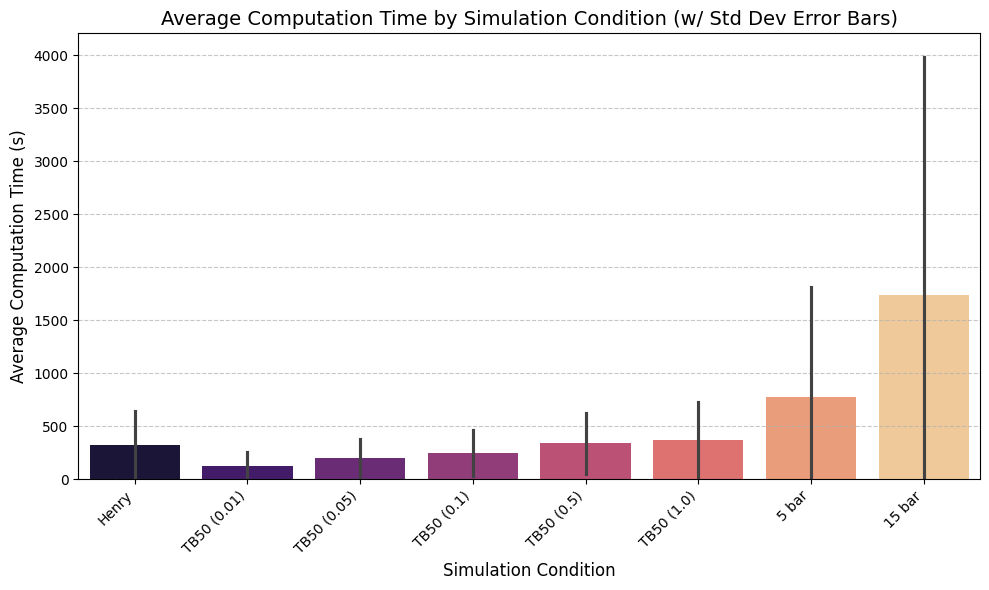

Average Time Bar Plot with Standard Deviation Error Bars generated.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# ----------------------------------------------------
# 1. 예시 데이터 로드 (이전 단계에서 사용된 데이터를 재구성)
# ----------------------------------------------------
df_data = df_reordered

# MOF 컬럼을 제외한 시간 컬럼 목록 정의
time_cols = df_data.columns.drop('MOF').tolist()

# 시각화 레이블 정의
condition_map = {
    'HENRY_AR_313_CORE': 'Henry',
    '5bar_AR_313_CORE': '5 bar',
    '15bar_AR_313_CORE': '15 bar',
    'time_below_50_313_0.01': 'TB50 (0.01)',
    'time_below_50_313_0.05': 'TB50 (0.05)',
    'time_below_50_313_0.1': 'TB50 (0.1)',
    'time_below_50_313_0.5': 'TB50 (0.5)', 
    'time_below_50_313_1': 'TB50 (1.0)'
}


# ----------------------------------------------------
# 2. 시각화: 조건별 평균 계산 시간 (Bar Plot with Standard Deviation)
# ----------------------------------------------------

# 데이터 Melt 및 레이블 적용
df_melted = df_data.melt(
    value_vars=time_cols,
    var_name='Condition',
    value_name='Computation Time (s)'
)
df_melted['Condition_Label'] = df_melted['Condition'].map(condition_map)

# 조건 순서 정의 (HENRY -> TB50s -> bar)
ordered_conditions = [condition_map[col] for col in time_cols]
df_melted['Condition_Label'] = pd.Categorical(
    df_melted['Condition_Label'], 
    categories=ordered_conditions, 
    ordered=True
)

plt.figure(figsize=(10, 6))
# 평균을 높이로 하는 막대 그래프 생성
# ci='sd' 옵션을 사용하여 표준편차(Standard Deviation)를 에러 바로 표시
sns.barplot(
    x='Condition_Label',
    y='Computation Time (s)',
    data=df_melted,
    ci='sd', # <--- 표준편차 에러 바 추가!
    palette="magma"
)
plt.title('Average Computation Time by Simulation Condition (w/ Std Dev Error Bars)', fontsize=14)
plt.xlabel('Simulation Condition', fontsize=12)
plt.ylabel('Average Computation Time (s)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() # 실제 환경에서 시각화
# plt.savefig('average_time_barplot_with_stddev.png')
print("Average Time Bar Plot with Standard Deviation Error Bars generated.")

In [ ]:
import os 
from  pathlib import Path 
CATBOOST_DIR = Path ("../try15_Ar313_0.01_15bar_Isotherm/")
os.listdir(CATBOOST_DIR / 'Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05'/ 'trial_001')
# ['df_train.csv',
#  'feature_importances_holdout_trial001.csv',
#  'hist_fraction_trial001.png',
#  'metrics_holdout_trial001.csv',
#  'model_params_trial001.json',
#  'Pipeline_trial001_20250928_205808.log',
#  'predictions_holdout_trial001.csv',
#  'sampling_info_trial001.json',
#  'scatter_sampling_trial001.png',
#  'test_indices_trial001.csv',
#  'train_indices_trial001.csv',
#  'train_qt_indices_trial001.csv',
#  'train_rd_indices_trial001.csv',
#  'X.csv',
#  'y.csv']

['df_train.csv',
 'feature_importances_holdout_trial001.csv',
 'hist_fraction_trial001.png',
 'metrics_holdout_trial001.csv',
 'model_params_trial001.json',
 'Pipeline_trial001_20250928_205808.log',
 'predictions_holdout_trial001.csv',
 'sampling_info_trial001.json',
 'scatter_sampling_trial001.png',
 'test_indices_trial001.csv',
 'train_indices_trial001.csv',
 'train_qt_indices_trial001.csv',
 'train_rd_indices_trial001.csv',
 'X.csv',
 'y.csv']

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 설정 변수
TRAIN_RATIOS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
TARGET_PRESSURE = 15
# 경로 설정 (사용자 제공)
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/") 
COMPTIMES_PATH = Path("./ComputationTimeSimulation/Ar_313K_TIME_20250929/Final_Computation_Time_Pivot_Table_Reordered.csv")
TARGET_COL = f'{TARGET_PRESSURE}bar_AR_313_CORE'

# 1. COMPTIMES DataFrame 준비
try:
    COMPTIMES = pd.read_csv(COMPTIMES_PATH)
except FileNotFoundError:
    print(f"Error: Computation time file not found at {COMPTIMES_PATH}. Cannot proceed.")
    raise

COMPTIMES_INDEXED = COMPTIMES.set_index('MOF')[[TARGET_COL]]

results = []

# ----------------------------------------------------
# 2. GCMC 시간 계산 (0.05 ~ 0.8 Ratio)
# ----------------------------------------------------
for TRAIN_RATIO in TRAIN_RATIOS:
    dir_name = f'Ar_313_0.01_to_{TARGET_PRESSURE}__struct+input__qt_then_rd__cat_TRAIN_RATIO{TRAIN_RATIO}_QTFRAC_{TRAIN_RATIO}'
    base_path = CATBOOST_DIR / dir_name / 'trial_001'
    
    try:
        TRAIN_DF = pd.read_csv(base_path / 'df_train.csv')
        PRED_DF = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
    except FileNotFoundError:
        print(f"Warning: ML files for TRAIN_RATIO {TRAIN_RATIO} not found. Skipping.")
        continue

    PRED_MOFS = set(PRED_DF['filename'])
    TRAIN_MOFS_GCMC = set(TRAIN_DF['filename']) - PRED_MOFS
    
    # GCMC MOFs가 없으면 0으로 처리 (오류 방지)
    if not TRAIN_MOFS_GCMC:
        GCMC_SAMPLING_TIME = 0.0
    else:
        df_gcmc_mofs = pd.DataFrame(list(TRAIN_MOFS_GCMC), columns=['MOF']).set_index('MOF')
        df_merged = df_gcmc_mofs.join(COMPTIMES_INDEXED, how='inner')
        GCMC_SAMPLING_TIME = df_merged[TARGET_COL].sum()
    
    GCMC_SAMPLING_TIME_H = GCMC_SAMPLING_TIME / 3600
    
    print(f"TRAIN_RATIO: {TRAIN_RATIO:.2f}, MOFs: {len(TRAIN_MOFS_GCMC)}, GCMC_TIME: {GCMC_SAMPLING_TIME_H:.2f} hours")
    
    results.append({
        'TRAIN_RATIO': TRAIN_RATIO,
        'GCMC_SAMPLING_TIME_H': GCMC_SAMPLING_TIME_H,
        'Dataset': 'ML Subset'
    })

# ----------------------------------------------------
# 3. 100% (Ratio = 1.0) 전체 GCMC 시간 계산 및 추가
# ----------------------------------------------------
TOTAL_GCMC_TIME_S = COMPTIMES_INDEXED[TARGET_COL].sum()
TOTAL_GCMC_TIME_H = TOTAL_GCMC_TIME_S / 3600

print(f"\nTOTAL GCMC TIME (Ratio 1.0): {TOTAL_GCMC_TIME_H:.2f} hours")

results.append({
    'TRAIN_RATIO': 1.0,
    'GCMC_SAMPLING_TIME_H': TOTAL_GCMC_TIME_H,
    'Dataset': 'Total GCMC (1.0)'
})

df_results = pd.DataFrame(results)

# TRAIN_RATIO를 범주형으로 변환하여 x축 순서를 보장
df_results['TRAIN_RATIO_STR'] = df_results['TRAIN_RATIO'].astype(str)
# x축 순서를 위한 명시적 카테고리 정의
# ML Subset의 Ratio는 소수점 두 자리로 표시하고, 1.0은 별도 처리
x_order = [str(r) for r in TRAIN_RATIOS] + ['1.0']
df_results['TRAIN_RATIO_STR'] = pd.Categorical(df_results['TRAIN_RATIO_STR'], categories=x_order, ordered=True)


# ----------------------------------------------------
# 4. 결과 시각화 (Bar Chart + Line Chart, Origin 스타일 개선)
# ----------------------------------------------------

plt.figure(figsize=(14, 8))

# 1. Bar plot: ML Subset 데이터 (회색 막대)
# TRAIN_RATIO가 1.0이 아닌 데이터만 barplot으로 그림
sns.barplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'ML Subset'],
    color='lightgray',
    label='GCMC Time for Training Subset',
    dodge=False
)

# 2. Line plot: ML Subset 데이터 (파란색 라인)
# TRAIN_RATIO가 1.0이 아닌 데이터만 lineplot으로 그림
sns.lineplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'ML Subset'],
    marker='o',
    color='blue',
    linewidth=2,
    linestyle='-',
    label='_nolegend_' # 이미 barplot에서 라벨을 달았으므로 라인에는 달지 않음
)

# 3. Scatterplot: Total GCMC (1.0) 데이터 (빨간색 다이아몬드)
# TRAIN_RATIO가 1.0인 데이터만 scatterplot으로 그림
sns.scatterplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'Total GCMC (1.0)'],
    marker='D', # 다이아몬드 마커
    s=2

SyntaxError: incomplete input (847185234.py, line 121)

In [57]:
base_path

WindowsPath('CATBOOST_RESULTS/Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.8_QTFRAC_0.8/trial_001')

In [54]:
results

[]

In [53]:
df_results

""


[0.05,
 0.1,
 0.15000000000000002,
 0.2,
 0.25,
 0.30000000000000004,
 0.35000000000000003,
 0.4,
 0.45,
 0.5,
 0.55,
 0.6000000000000001,
 0.65,
 0.7000000000000001,
 0.75,
 0.8]

TRAIN_RATIO: 0.05, MOFs: 388, GCMC_TIME: 190.28 hours
TRAIN_RATIO: 0.10, MOFs: 776, GCMC_TIME: 411.05 hours
TRAIN_RATIO: 0.15, MOFs: 1164, GCMC_TIME: 606.98 hours
TRAIN_RATIO: 0.20, MOFs: 1552, GCMC_TIME: 787.65 hours
TRAIN_RATIO: 0.25, MOFs: 1940, GCMC_TIME: 972.48 hours
TRAIN_RATIO: 0.30, MOFs: 2328, GCMC_TIME: 1158.59 hours
TRAIN_RATIO: 0.35, MOFs: 2716, GCMC_TIME: 1420.42 hours
TRAIN_RATIO: 0.40, MOFs: 3104, GCMC_TIME: 1535.13 hours
TRAIN_RATIO: 0.45, MOFs: 3492, GCMC_TIME: 1706.11 hours
TRAIN_RATIO: 0.50, MOFs: 3880, GCMC_TIME: 1889.91 hours
TRAIN_RATIO: 0.55, MOFs: 4268, GCMC_TIME: 2096.69 hours
TRAIN_RATIO: 0.60, MOFs: 4656, GCMC_TIME: 2284.64 hours
TRAIN_RATIO: 0.65, MOFs: 5044, GCMC_TIME: 2437.51 hours
TRAIN_RATIO: 0.70, MOFs: 5432, GCMC_TIME: 2629.96 hours
TRAIN_RATIO: 0.75, MOFs: 5820, GCMC_TIME: 2836.11 hours
TRAIN_RATIO: 0.80, MOFs: 6208, GCMC_TIME: 3010.06 hours

TOTAL GCMC TIME (Ratio 1.0): 3739.47 hours


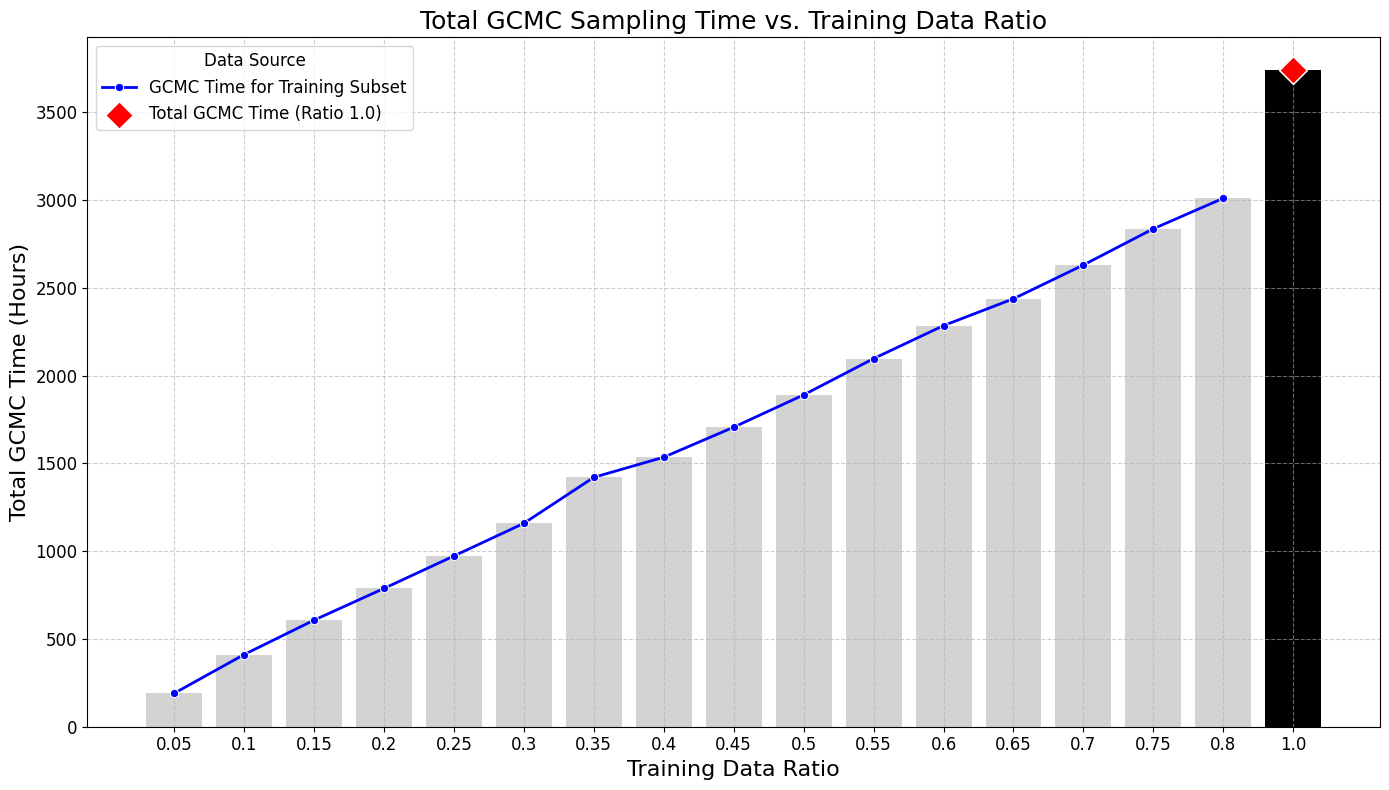


GCMC Sampling Time visualization with Bar & Line chart (Final style) completed. Total GCMC (1.0) now has a black bar.


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 설정 변수 (코드는 변경 없음)
TRAIN_RATIOS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
TARGET_PRESSURE = 15
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/") 
COMPTIMES_PATH = Path("./ComputationTimeSimulation/Ar_313K_TIME_20250929/Final_Computation_Time_Pivot_Table_Reordered.csv")
TARGET_COL = f'{TARGET_PRESSURE}bar_AR_313_CORE'

# 1. COMPTIMES DataFrame 준비 (코드 변경 없음)
try:
    COMPTIMES = pd.read_csv(COMPTIMES_PATH)
except FileNotFoundError:
    print(f"Error: Computation time file not found at {COMPTIMES_PATH}. Cannot proceed.")
    raise

COMPTIMES_INDEXED = COMPTIMES.set_index('MOF')[[TARGET_COL]]
results = []

# ----------------------------------------------------
# 2. GCMC 시간 계산 (0.05 ~ 0.8 Ratio) (코드 변경 없음)
# ----------------------------------------------------
for TRAIN_RATIO in TRAIN_RATIOS:
    dir_name = f'Ar_313_0.01_to_{TARGET_PRESSURE}__struct+input__qt_then_rd__cat_TRAIN_RATIO{TRAIN_RATIO}_QTFRAC_{TRAIN_RATIO}'
    base_path = CATBOOST_DIR / dir_name / 'trial_001'
    
    try:
        TRAIN_DF = pd.read_csv(base_path / 'df_train.csv')
        PRED_DF = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
    except FileNotFoundError:
        print(f"Warning: ML files for TRAIN_RATIO {TRAIN_RATIO} not found. Skipping.")
        continue

    PRED_MOFS = set(PRED_DF['filename'])
    TRAIN_MOFS_GCMC = set(TRAIN_DF['filename']) - PRED_MOFS
    
    if not TRAIN_MOFS_GCMC:
        GCMC_SAMPLING_TIME = 0.0
    else:
        df_gcmc_mofs = pd.DataFrame(list(TRAIN_MOFS_GCMC), columns=['MOF']).set_index('MOF')
        df_merged = df_gcmc_mofs.join(COMPTIMES_INDEXED, how='inner')
        GCMC_SAMPLING_TIME = df_merged[TARGET_COL].sum()
    
    GCMC_SAMPLING_TIME_H = GCMC_SAMPLING_TIME / 3600
    
    print(f"TRAIN_RATIO: {TRAIN_RATIO:.2f}, MOFs: {len(TRAIN_MOFS_GCMC)}, GCMC_TIME: {GCMC_SAMPLING_TIME_H:.2f} hours")
    
    results.append({
        'TRAIN_RATIO': TRAIN_RATIO,
        'GCMC_SAMPLING_TIME_H': GCMC_SAMPLING_TIME_H,
        'Dataset': 'ML Subset'
    })

# ----------------------------------------------------
# 3. 100% (Ratio = 1.0) 전체 GCMC 시간 계산 및 추가 (코드 변경 없음)
# ----------------------------------------------------
TOTAL_GCMC_TIME_S = COMPTIMES_INDEXED[TARGET_COL].sum()
TOTAL_GCMC_TIME_H = TOTAL_GCMC_TIME_S / 3600

print(f"\nTOTAL GCMC TIME (Ratio 1.0): {TOTAL_GCMC_TIME_H:.2f} hours")

results.append({
    'TRAIN_RATIO': 1.0,
    'GCMC_SAMPLING_TIME_H': TOTAL_GCMC_TIME_H,
    'Dataset': 'Total GCMC (1.0)'
})

df_results = pd.DataFrame(results)

df_results['TRAIN_RATIO_STR'] = df_results['TRAIN_RATIO'].astype(str)
x_order = [str(r) for r in TRAIN_RATIOS] + ['1.0']
df_results['TRAIN_RATIO_STR'] = pd.Categorical(df_results['TRAIN_RATIO_STR'], categories=x_order, ordered=True)


# ----------------------------------------------------
# 4. 결과 시각화 (Total GCMC에도 Bar plot 추가)
# ----------------------------------------------------

plt.figure(figsize=(14, 8))

# 1. Bar plot: 모든 데이터 (ML Subset + Total GCMC)를 검은색 막대로 그립니다.
# 'Dataset' 컬럼을 hue로 사용하여, 각 데이터셋에 다른 색상을 지정합니다.
# ML Subset은 'lightgray'로, Total GCMC (1.0)은 'black'으로 지정합니다.
custom_palette = {'ML Subset': 'lightgray', 'Total GCMC (1.0)': 'black'}

sns.barplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    hue='Dataset', # Dataset 기준으로 색상을 나눔
    data=df_results,
    palette=custom_palette,
    dodge=False, # 막대가 겹쳐지지 않도록
    # 범례에 Bar plot이 두 번 표시되는 것을 막기 위해 label은 추가하지 않음
)

# 2. Line plot: ML Subset 데이터 (파란색 라인)
# 이 플롯은 Bar plot 위에 덧그려져 추세를 보여줍니다.
sns.lineplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'ML Subset'],
    marker='o',
    color='blue',
    linewidth=2,
    linestyle='-',
    label='GCMC Time for Training Subset'
)

# 3. Scatterplot: Total GCMC (1.0) 데이터 (빨간색 다이아몬드)
# 이 플롯은 Bar plot 위에 덧그려져 1.0 지점을 강조합니다.
sns.scatterplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'Total GCMC (1.0)'],
    marker='D', 
    s=200,      
    color='red',
    label='Total GCMC Time (Ratio 1.0)',
    zorder=5 
)

plt.title('Total GCMC Sampling Time vs. Training Data Ratio', fontsize=18)
plt.xlabel('Training Data Ratio', fontsize=16)
plt.ylabel(f'Total GCMC Time (Hours)', fontsize=16)

# Barplot에서 생성된 범례 항목을 수동으로 제거하고 Line/Scatterplot 범례만 표시
handles, labels = plt.gca().get_legend_handles_labels()
# Bar plot 항목 ('ML Subset'과 'Total GCMC (1.0)'의 Bar)을 제거하고 Line/Scatterplot 항목만 남깁니다.
line_scatter_handles = [h for i, h in enumerate(handles) if labels[i] not in ['ML Subset', 'Total GCMC (1.0)']]
line_scatter_labels = [l for l in labels if l not in ['ML Subset', 'Total GCMC (1.0)']]

plt.legend(line_scatter_handles, line_scatter_labels, 
           title='Data Source', loc='upper left', fontsize=12, title_fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show() 

print("\nGCMC Sampling Time visualization with Bar & Line chart (Final style) completed. Total GCMC (1.0) now has a black bar.")

TRAIN_RATIO: 0.05, MOFs: 388, GCMC_TIME: 95.48 hours
TRAIN_RATIO: 0.10, MOFs: 776, GCMC_TIME: 201.85 hours
TRAIN_RATIO: 0.15, MOFs: 1164, GCMC_TIME: 293.78 hours
TRAIN_RATIO: 0.20, MOFs: 1552, GCMC_TIME: 380.27 hours
TRAIN_RATIO: 0.25, MOFs: 1940, GCMC_TIME: 464.68 hours
TRAIN_RATIO: 0.30, MOFs: 2328, GCMC_TIME: 557.15 hours
TRAIN_RATIO: 0.35, MOFs: 2716, GCMC_TIME: 672.20 hours
TRAIN_RATIO: 0.40, MOFs: 3104, GCMC_TIME: 725.28 hours
TRAIN_RATIO: 0.45, MOFs: 3492, GCMC_TIME: 807.20 hours
TRAIN_RATIO: 0.50, MOFs: 3880, GCMC_TIME: 887.56 hours
TRAIN_RATIO: 0.55, MOFs: 4268, GCMC_TIME: 973.43 hours
TRAIN_RATIO: 0.60, MOFs: 4656, GCMC_TIME: 1060.03 hours
TRAIN_RATIO: 0.65, MOFs: 5044, GCMC_TIME: 1128.24 hours
TRAIN_RATIO: 0.70, MOFs: 5432, GCMC_TIME: 1209.44 hours
TRAIN_RATIO: 0.75, MOFs: 5820, GCMC_TIME: 1294.02 hours
TRAIN_RATIO: 0.80, MOFs: 6208, GCMC_TIME: 1370.95 hours

TOTAL GCMC TIME (Ratio 1.0): 1680.46 hours


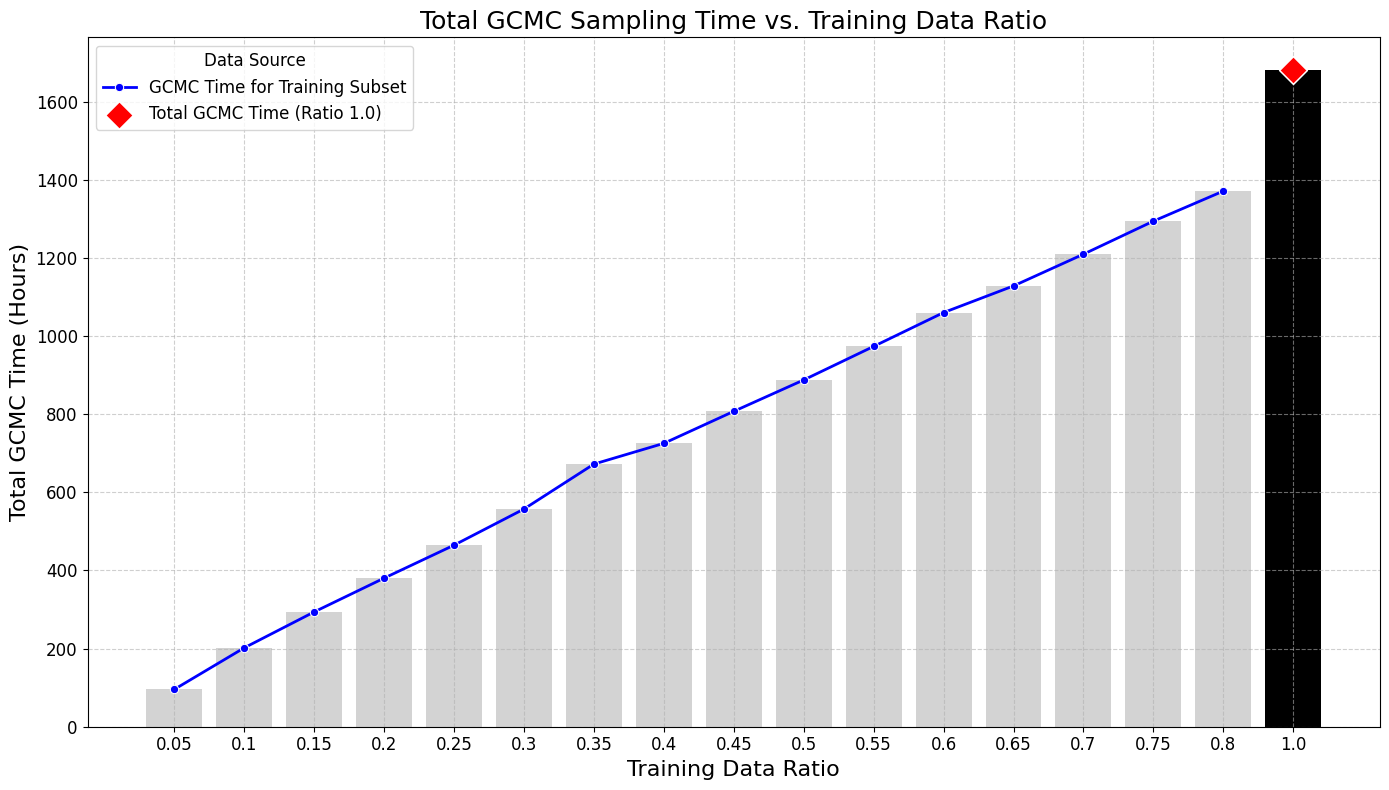


GCMC Sampling Time visualization with Bar & Line chart (Final style) completed. Total GCMC (1.0) now has a black bar.


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 설정 변수 (코드는 변경 없음)
TRAIN_RATIOS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
TARGET_PRESSURE = 5
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/") 
COMPTIMES_PATH = Path("./ComputationTimeSimulation/Ar_313K_TIME_20250929/Final_Computation_Time_Pivot_Table_Reordered.csv")
TARGET_COL = f'{TARGET_PRESSURE}bar_AR_313_CORE'

# 1. COMPTIMES DataFrame 준비 (코드 변경 없음)
try:
    COMPTIMES = pd.read_csv(COMPTIMES_PATH)
except FileNotFoundError:
    print(f"Error: Computation time file not found at {COMPTIMES_PATH}. Cannot proceed.")
    raise

COMPTIMES_INDEXED = COMPTIMES.set_index('MOF')[[TARGET_COL]]
results = []

# ----------------------------------------------------
# 2. GCMC 시간 계산 (0.05 ~ 0.8 Ratio) (코드 변경 없음)
# ----------------------------------------------------
for TRAIN_RATIO in TRAIN_RATIOS:
    dir_name = f'Ar_313_0.01_to_{TARGET_PRESSURE}__struct+input__qt_then_rd__cat_TRAIN_RATIO{TRAIN_RATIO}_QTFRAC_{TRAIN_RATIO}'
    base_path = CATBOOST_DIR / dir_name / 'trial_001'
    
    try:
        TRAIN_DF = pd.read_csv(base_path / 'df_train.csv')
        PRED_DF = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
    except FileNotFoundError:
        print(f"Warning: ML files for TRAIN_RATIO {TRAIN_RATIO} not found. Skipping.")
        continue

    PRED_MOFS = set(PRED_DF['filename'])
    TRAIN_MOFS_GCMC = set(TRAIN_DF['filename']) - PRED_MOFS
    
    if not TRAIN_MOFS_GCMC:
        GCMC_SAMPLING_TIME = 0.0
    else:
        df_gcmc_mofs = pd.DataFrame(list(TRAIN_MOFS_GCMC), columns=['MOF']).set_index('MOF')
        df_merged = df_gcmc_mofs.join(COMPTIMES_INDEXED, how='inner')
        GCMC_SAMPLING_TIME = df_merged[TARGET_COL].sum()
    
    GCMC_SAMPLING_TIME_H = GCMC_SAMPLING_TIME / 3600
    
    print(f"TRAIN_RATIO: {TRAIN_RATIO:.2f}, MOFs: {len(TRAIN_MOFS_GCMC)}, GCMC_TIME: {GCMC_SAMPLING_TIME_H:.2f} hours")
    
    results.append({
        'TRAIN_RATIO': TRAIN_RATIO,
        'GCMC_SAMPLING_TIME_H': GCMC_SAMPLING_TIME_H,
        'Dataset': 'ML Subset'
    })

# ----------------------------------------------------
# 3. 100% (Ratio = 1.0) 전체 GCMC 시간 계산 및 추가 (코드 변경 없음)
# ----------------------------------------------------
TOTAL_GCMC_TIME_S = COMPTIMES_INDEXED[TARGET_COL].sum()
TOTAL_GCMC_TIME_H = TOTAL_GCMC_TIME_S / 3600

print(f"\nTOTAL GCMC TIME (Ratio 1.0): {TOTAL_GCMC_TIME_H:.2f} hours")

results.append({
    'TRAIN_RATIO': 1.0,
    'GCMC_SAMPLING_TIME_H': TOTAL_GCMC_TIME_H,
    'Dataset': 'Total GCMC (1.0)'
})

df_results = pd.DataFrame(results)

df_results['TRAIN_RATIO_STR'] = df_results['TRAIN_RATIO'].astype(str)
x_order = [str(r) for r in TRAIN_RATIOS] + ['1.0']
df_results['TRAIN_RATIO_STR'] = pd.Categorical(df_results['TRAIN_RATIO_STR'], categories=x_order, ordered=True)


# ----------------------------------------------------
# 4. 결과 시각화 (Total GCMC에도 Bar plot 추가)
# ----------------------------------------------------

plt.figure(figsize=(14, 8))

# 1. Bar plot: 모든 데이터 (ML Subset + Total GCMC)를 검은색 막대로 그립니다.
# 'Dataset' 컬럼을 hue로 사용하여, 각 데이터셋에 다른 색상을 지정합니다.
# ML Subset은 'lightgray'로, Total GCMC (1.0)은 'black'으로 지정합니다.
custom_palette = {'ML Subset': 'lightgray', 'Total GCMC (1.0)': 'black'}

sns.barplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    hue='Dataset', # Dataset 기준으로 색상을 나눔
    data=df_results,
    palette=custom_palette,
    dodge=False, # 막대가 겹쳐지지 않도록
    # 범례에 Bar plot이 두 번 표시되는 것을 막기 위해 label은 추가하지 않음
)

# 2. Line plot: ML Subset 데이터 (파란색 라인)
# 이 플롯은 Bar plot 위에 덧그려져 추세를 보여줍니다.
sns.lineplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'ML Subset'],
    marker='o',
    color='blue',
    linewidth=2,
    linestyle='-',
    label='GCMC Time for Training Subset'
)

# 3. Scatterplot: Total GCMC (1.0) 데이터 (빨간색 다이아몬드)
# 이 플롯은 Bar plot 위에 덧그려져 1.0 지점을 강조합니다.
sns.scatterplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'Total GCMC (1.0)'],
    marker='D', 
    s=200,      
    color='red',
    label='Total GCMC Time (Ratio 1.0)',
    zorder=5 
)

plt.title('Total GCMC Sampling Time vs. Training Data Ratio', fontsize=18)
plt.xlabel('Training Data Ratio', fontsize=16)
plt.ylabel(f'Total GCMC Time (Hours)', fontsize=16)

# Barplot에서 생성된 범례 항목을 수동으로 제거하고 Line/Scatterplot 범례만 표시
handles, labels = plt.gca().get_legend_handles_labels()
# Bar plot 항목 ('ML Subset'과 'Total GCMC (1.0)'의 Bar)을 제거하고 Line/Scatterplot 항목만 남깁니다.
line_scatter_handles = [h for i, h in enumerate(handles) if labels[i] not in ['ML Subset', 'Total GCMC (1.0)']]
line_scatter_labels = [l for l in labels if l not in ['ML Subset', 'Total GCMC (1.0)']]

plt.legend(line_scatter_handles, line_scatter_labels, 
           title='Data Source', loc='upper left', fontsize=12, title_fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show() 

print("\nGCMC Sampling Time visualization with Bar & Line chart (Final style) completed. Total GCMC (1.0) now has a black bar.")

TRAIN_RATIO: 0.05, MOFs: 388, GCMC_TIME: 47.98 hours
TRAIN_RATIO: 0.10, MOFs: 776, GCMC_TIME: 95.90 hours
TRAIN_RATIO: 0.15, MOFs: 1164, GCMC_TIME: 137.19 hours
TRAIN_RATIO: 0.20, MOFs: 1552, GCMC_TIME: 181.47 hours
TRAIN_RATIO: 0.25, MOFs: 1940, GCMC_TIME: 219.32 hours
TRAIN_RATIO: 0.30, MOFs: 2328, GCMC_TIME: 264.85 hours
TRAIN_RATIO: 0.35, MOFs: 2716, GCMC_TIME: 310.60 hours
TRAIN_RATIO: 0.40, MOFs: 3104, GCMC_TIME: 344.18 hours
TRAIN_RATIO: 0.45, MOFs: 3492, GCMC_TIME: 382.88 hours
TRAIN_RATIO: 0.50, MOFs: 3880, GCMC_TIME: 418.60 hours
TRAIN_RATIO: 0.55, MOFs: 4268, GCMC_TIME: 461.79 hours
TRAIN_RATIO: 0.60, MOFs: 4656, GCMC_TIME: 499.10 hours
TRAIN_RATIO: 0.65, MOFs: 5044, GCMC_TIME: 534.42 hours
TRAIN_RATIO: 0.70, MOFs: 5432, GCMC_TIME: 569.95 hours
TRAIN_RATIO: 0.75, MOFs: 5820, GCMC_TIME: 609.26 hours
TRAIN_RATIO: 0.80, MOFs: 6208, GCMC_TIME: 645.01 hours

TOTAL GCMC TIME (Ratio 1.0): 792.42 hours


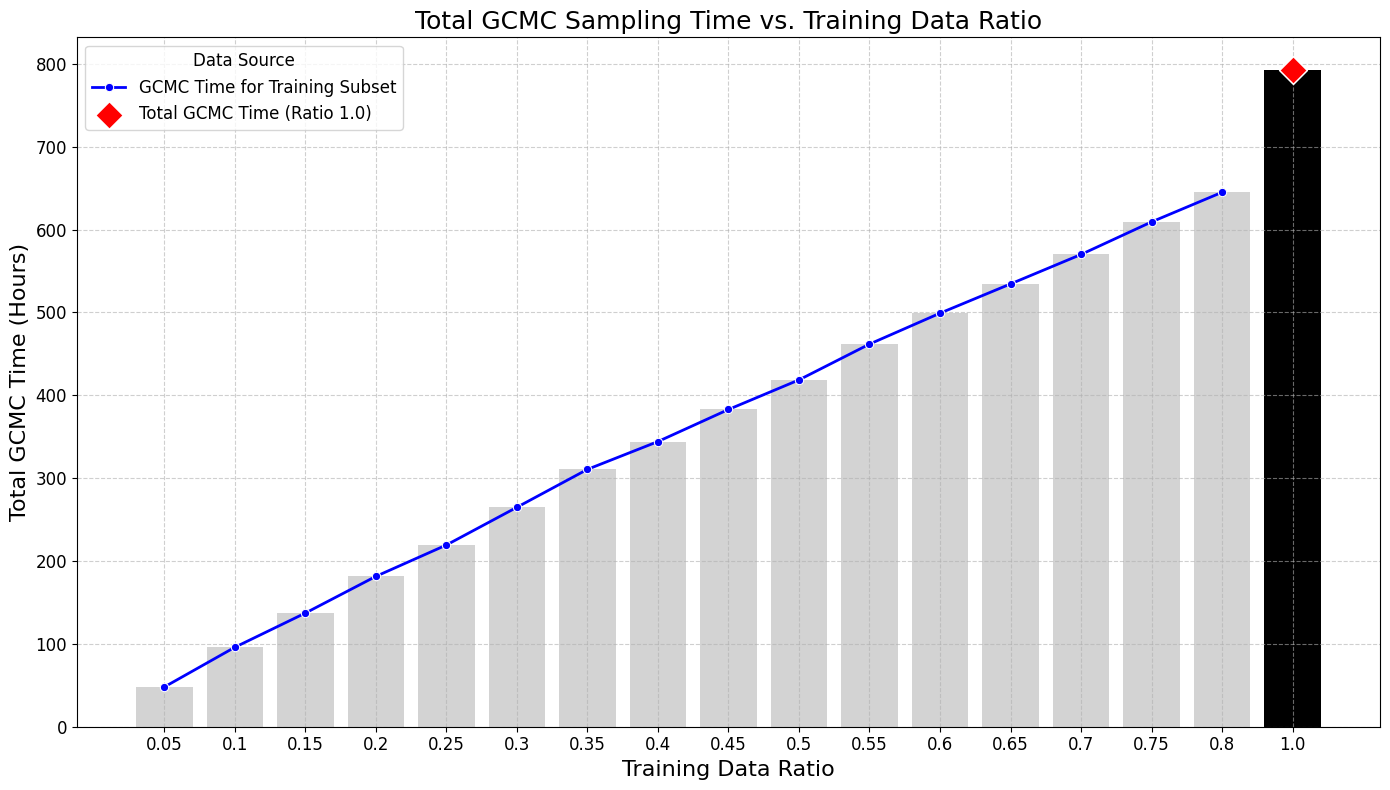


GCMC Sampling Time visualization with Bar & Line chart (Final style) completed. Total GCMC (1.0) now has a black bar.


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 설정 변수 (코드는 변경 없음)
TRAIN_RATIOS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
TARGET_PRESSURE = 15
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/") 
COMPTIMES_PATH = Path("./ComputationTimeSimulation/Ar_313K_TIME_20250929/Final_Computation_Time_Pivot_Table_Reordered.csv")
TARGET_COL ="time_below_50_313_1"

# 1. COMPTIMES DataFrame 준비 (코드 변경 없음)
try:
    COMPTIMES = pd.read_csv(COMPTIMES_PATH)
except FileNotFoundError:
    print(f"Error: Computation time file not found at {COMPTIMES_PATH}. Cannot proceed.")
    raise

COMPTIMES_INDEXED = COMPTIMES.set_index('MOF')[[TARGET_COL]]
results = []

# ----------------------------------------------------
# 2. GCMC 시간 계산 (0.05 ~ 0.8 Ratio) (코드 변경 없음)
# ----------------------------------------------------
for TRAIN_RATIO in TRAIN_RATIOS:
    dir_name = f'Ar_313_0.01_to_{TARGET_PRESSURE}__struct+input__qt_then_rd__cat_TRAIN_RATIO{TRAIN_RATIO}_QTFRAC_{TRAIN_RATIO}'
    base_path = CATBOOST_DIR / dir_name / 'trial_001'
    
    try:
        TRAIN_DF = pd.read_csv(base_path / 'df_train.csv')
        PRED_DF = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
    except FileNotFoundError:
        print(f"Warning: ML files for TRAIN_RATIO {TRAIN_RATIO} not found. Skipping.")
        continue

    PRED_MOFS = set(PRED_DF['filename'])
    TRAIN_MOFS_GCMC = set(TRAIN_DF['filename']) - PRED_MOFS
    
    if not TRAIN_MOFS_GCMC:
        GCMC_SAMPLING_TIME = 0.0
    else:
        df_gcmc_mofs = pd.DataFrame(list(TRAIN_MOFS_GCMC), columns=['MOF']).set_index('MOF')
        df_merged = df_gcmc_mofs.join(COMPTIMES_INDEXED, how='inner')
        GCMC_SAMPLING_TIME = df_merged[TARGET_COL].sum()
    
    GCMC_SAMPLING_TIME_H = GCMC_SAMPLING_TIME / 3600
    
    print(f"TRAIN_RATIO: {TRAIN_RATIO:.2f}, MOFs: {len(TRAIN_MOFS_GCMC)}, GCMC_TIME: {GCMC_SAMPLING_TIME_H:.2f} hours")
    
    results.append({
        'TRAIN_RATIO': TRAIN_RATIO,
        'GCMC_SAMPLING_TIME_H': GCMC_SAMPLING_TIME_H,
        'Dataset': 'ML Subset'
    })

# ----------------------------------------------------
# 3. 100% (Ratio = 1.0) 전체 GCMC 시간 계산 및 추가 (코드 변경 없음)
# ----------------------------------------------------
TOTAL_GCMC_TIME_S = COMPTIMES_INDEXED[TARGET_COL].sum()
TOTAL_GCMC_TIME_H = TOTAL_GCMC_TIME_S / 3600

print(f"\nTOTAL GCMC TIME (Ratio 1.0): {TOTAL_GCMC_TIME_H:.2f} hours")

results.append({
    'TRAIN_RATIO': 1.0,
    'GCMC_SAMPLING_TIME_H': TOTAL_GCMC_TIME_H,
    'Dataset': 'Total GCMC (1.0)'
})

df_results = pd.DataFrame(results)

df_results['TRAIN_RATIO_STR'] = df_results['TRAIN_RATIO'].astype(str)
x_order = [str(r) for r in TRAIN_RATIOS] + ['1.0']
df_results['TRAIN_RATIO_STR'] = pd.Categorical(df_results['TRAIN_RATIO_STR'], categories=x_order, ordered=True)


# ----------------------------------------------------
# 4. 결과 시각화 (Total GCMC에도 Bar plot 추가)
# ----------------------------------------------------

plt.figure(figsize=(14, 8))

# 1. Bar plot: 모든 데이터 (ML Subset + Total GCMC)를 검은색 막대로 그립니다.
# 'Dataset' 컬럼을 hue로 사용하여, 각 데이터셋에 다른 색상을 지정합니다.
# ML Subset은 'lightgray'로, Total GCMC (1.0)은 'black'으로 지정합니다.
custom_palette = {'ML Subset': 'lightgray', 'Total GCMC (1.0)': 'black'}

sns.barplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    hue='Dataset', # Dataset 기준으로 색상을 나눔
    data=df_results,
    palette=custom_palette,
    dodge=False, # 막대가 겹쳐지지 않도록
    # 범례에 Bar plot이 두 번 표시되는 것을 막기 위해 label은 추가하지 않음
)

# 2. Line plot: ML Subset 데이터 (파란색 라인)
# 이 플롯은 Bar plot 위에 덧그려져 추세를 보여줍니다.
sns.lineplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'ML Subset'],
    marker='o',
    color='blue',
    linewidth=2,
    linestyle='-',
    label='GCMC Time for Training Subset'
)

# 3. Scatterplot: Total GCMC (1.0) 데이터 (빨간색 다이아몬드)
# 이 플롯은 Bar plot 위에 덧그려져 1.0 지점을 강조합니다.
sns.scatterplot(
    x='TRAIN_RATIO_STR',
    y='GCMC_SAMPLING_TIME_H',
    data=df_results[df_results['Dataset'] == 'Total GCMC (1.0)'],
    marker='D', 
    s=200,      
    color='red',
    label='Total GCMC Time (Ratio 1.0)',
    zorder=5 
)

plt.title('Total GCMC Sampling Time vs. Training Data Ratio', fontsize=18)
plt.xlabel('Training Data Ratio', fontsize=16)
plt.ylabel(f'Total GCMC Time (Hours)', fontsize=16)

# Barplot에서 생성된 범례 항목을 수동으로 제거하고 Line/Scatterplot 범례만 표시
handles, labels = plt.gca().get_legend_handles_labels()
# Bar plot 항목 ('ML Subset'과 'Total GCMC (1.0)'의 Bar)을 제거하고 Line/Scatterplot 항목만 남깁니다.
line_scatter_handles = [h for i, h in enumerate(handles) if labels[i] not in ['ML Subset', 'Total GCMC (1.0)']]
line_scatter_labels = [l for l in labels if l not in ['ML Subset', 'Total GCMC (1.0)']]

plt.legend(line_scatter_handles, line_scatter_labels, 
           title='Data Source', loc='upper left', fontsize=12, title_fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show() 

print("\nGCMC Sampling Time visualization with Bar & Line chart (Final style) completed. Total GCMC (1.0) now has a black bar.")

--- Calculating GCMC times for 1 bar ---
--- Calculating GCMC times for 5 bar ---
--- Calculating GCMC times for 15 bar ---


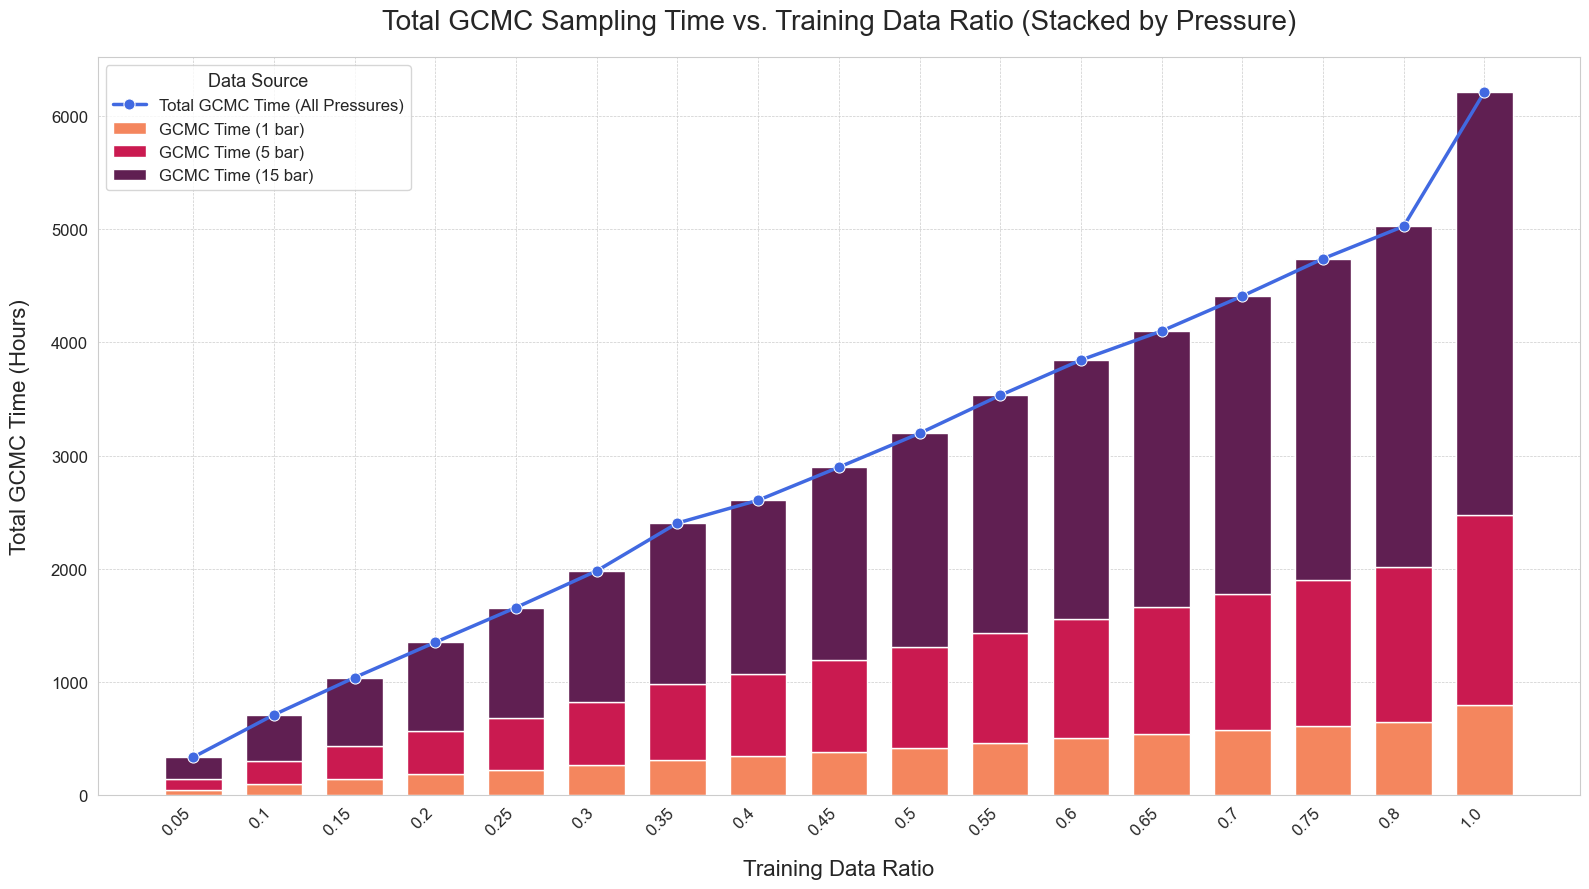


🚀 Stacked Bar chart visualization with top line plot completed.


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# ----------------------------------------------------
# 1. 설정 변수 정의
# ----------------------------------------------------
TRAIN_RATIOS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/") 
COMPTIMES_PATH = Path("./ComputationTimeSimulation/Ar_313K_TIME_20250929/Final_Computation_Time_Pivot_Table_Reordered.csv")

# 각 압력 조건에 대한 설정 (압력, 대상 컬럼, ML 결과 폴더명 압력)
# 참고: 1 bar에 해당하는 컬럼명은 제공된 코드에 따라 'time_below_50_313_1'로 가정합니다.
pressure_configs = [
    {'pressure': 1,  'col': 'time_below_50_313_1', 'ml_pressure': 15}, # 1 bar 데이터는 15 bar ML 폴더 구조를 사용한다고 가정
    {'pressure': 5,  'col': '5bar_AR_313_CORE',    'ml_pressure': 5},
    {'pressure': 15, 'col': '15bar_AR_313_CORE',   'ml_pressure': 15},
]

# ----------------------------------------------------
# 2. GCMC 시간 계산 함수
# ----------------------------------------------------
def calculate_gcmc_times(target_col, ml_pressure, comptimes_df):
    """지정된 압력 조건에 대해 TRAIN_RATIO별 GCMC 시간을 계산하는 함수"""
    results = []
    comptimes_indexed = comptimes_df.set_index('MOF')[[target_col]]

    # ML Subset (0.05 ~ 0.8) 시간 계산
    for ratio in TRAIN_RATIOS:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO{ratio}_QTFRAC_{ratio}'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        
        try:
            train_df = pd.read_csv(base_path / 'df_train.csv')
            pred_df = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
        except FileNotFoundError:
            print(f"Warning: ML files for RATIO {ratio} (Pressure: {ml_pressure} bar config) not found. Skipping.")
            continue

        pred_mofs = set(pred_df['filename'])
        train_mofs_gcmc = set(train_df['filename']) - pred_mofs
        
        gcmc_sampling_time = 0.0
        if train_mofs_gcmc:
            df_gcmc_mofs = pd.DataFrame(list(train_mofs_gcmc), columns=['MOF']).set_index('MOF')
            df_merged = df_gcmc_mofs.join(comptimes_indexed, how='inner')
            gcmc_sampling_time = df_merged[target_col].sum()
        
        results.append({'TRAIN_RATIO': ratio, 'GCMC_TIME_H': gcmc_sampling_time / 3600})

    # Total GCMC (Ratio 1.0) 시간 계산
    total_gcmc_time_h = comptimes_indexed[target_col].sum() / 3600
    results.append({'TRAIN_RATIO': 1.0, 'GCMC_TIME_H': total_gcmc_time_h})

    return pd.DataFrame(results).set_index('TRAIN_RATIO')

# ----------------------------------------------------
# 3. 데이터 취합 및 전처리
# ----------------------------------------------------
try:
    COMPTIMES = pd.read_csv(COMPTIMES_PATH)
except FileNotFoundError:
    print(f"Error: Computation time file not found at {COMPTIMES_PATH}. Cannot proceed.")
    raise

# 각 압력 조건별 시간 계산 및 병합
all_results = {}
for config in pressure_configs:
    pressure = config['pressure']
    print(f"--- Calculating GCMC times for {pressure} bar ---")
    time_df = calculate_gcmc_times(config['col'], config['ml_pressure'], COMPTIMES)
    all_results[f'Time_{pressure}bar_H'] = time_df['GCMC_TIME_H']

# 최종 플롯용 데이터프레임 생성
df_plot = pd.DataFrame(all_results)
df_plot['Total_Time_H'] = df_plot.sum(axis=1) # 라인 플롯을 위한 총합 계산
df_plot = df_plot.sort_index() # 비율 순으로 정렬

# X축 레이블 준비
df_plot['TRAIN_RATIO_STR'] = df_plot.index.astype(str)

# ----------------------------------------------------
# 4. 스택 바 + 라인 차트 시각화 (Origin 스타일)
# ----------------------------------------------------
sns.set_style("whitegrid")
plt.figure(figsize=(16, 9))

# 스택 바를 위한 설정
pressure_cols = [f'Time_{p["pressure"]}bar_H' for p in pressure_configs]
labels = [f'GCMC Time ({p["pressure"]} bar)' for p in pressure_configs]
colors = sns.color_palette("rocket_r", n_colors=len(pressure_cols))

# 스택 바 그리기
bottom = np.zeros(len(df_plot))
for i, col in enumerate(pressure_cols):
    plt.bar(
        df_plot['TRAIN_RATIO_STR'],
        df_plot[col],
        bottom=bottom,
        color=colors[i],
        label=labels[i],
        width=0.7 # 막대 너비 조절
    )
    bottom += df_plot[col].values # 다음 막대를 위해 현재 막대 높이를 더함

# 최상단 라인 플롯 그리기
sns.lineplot(
    x='TRAIN_RATIO_STR',
    y='Total_Time_H',
    data=df_plot,
    marker='o',
    markersize=8,
    color='royalblue',
    linewidth=2.5,
    label='Total GCMC Time (All Pressures)'
)

# --- 차트 디자인 (타이틀, 레이블, 폰트 등) ---
plt.title('Total GCMC Sampling Time vs. Training Data Ratio (Stacked by Pressure)', fontsize=20, pad=20)
plt.xlabel('Training Data Ratio', fontsize=16, labelpad=15)
plt.ylabel('Total GCMC Time (Hours)', fontsize=16, labelpad=15)

# X축 틱 레이블 회전하여 겹침 방지
plt.xticks(rotation=45, ha='right', fontsize=12) 
plt.yticks(fontsize=12)

# 범례 설정
plt.legend(title='Data Source', loc='upper left', fontsize=12, title_fontsize=13)

# Y축 범위 및 그리드
plt.ylim(0)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 레이아웃 최적화
plt.tight_layout()
plt.show()

print("\n🚀 Stacked Bar chart visualization with top line plot completed.")

In [120]:
def Make_Uptake_list(ml_pressure, target_fraction, col):
    if target_fraction != 1.0:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO{target_fraction}_QTFRAC_{target_fraction}'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        pred_df = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
        pred_mofs = set(pred_df['filename'])

        UPTAKE_LIST = None
        train_mofs_gcmc = set(train_df['filename']) - pred_mofs
        train_UPTAKES = train_df[train_df['filename'].isin(train_mofs_gcmc)][["filename", "Output"]]
        test_UPTAKES = pred_df[["filename", "y_pred"]]
        UPTAKE_LIST = pd.concat([train_UPTAKES.rename(columns={"Output": "Uptake"}), test_UPTAKES.rename(columns={"y_pred": "Uptake"})])
    else:
        # 이럴땐 걍 0.05로 고정 어차피 Output 열은 Ground Truth니까
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        UPTAKE_LIST = train_df[["filename", "Output"]].rename(columns={"Output": "Uptake"})

    if UPTAKE_LIST is None:
        print(f"Warning: No UPTAKE_LIST for RATIO {target_fraction} (Pressure: {ml_pressure} bar config). Skipping.")
        
    return UPTAKE_LIST

In [ ]:
Make_Uptake_list(1, 1, "")

Step 1: Preparing and merging uptake data...
Data shape before cleaning: (7760, 4)
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting Sips isotherm model for each MOF...


⚙️  Fitting Sips Model:   0%|          | 0/7760 [00:00<?, ?it/s]

------------------------------

✅ Sips model fitting process complete.
  - ✔️ Successful fits: 6970
  - ❌ Failed fits:     790
Total MOFs processed: 7760
------------------------------

Here are some example fitted parameters from successful fits:
  - 1499489-acs.cgd.6b01265_1499490_clean: K1=11.0905, K2=0.0444, K3=0.9706
  - acs.cgd.5b01554_VAGNUP1452791_clean: K1=4.0347, K2=0.0276, K3=1.0069
  - acs.chemmater.5b03723_cm5b03723_si_004_clean: K1=6.0820, K2=0.1285, K3=1.0723
  - acs.chemmater.5b03723_cm5b03723_si_005_clean: K1=18.3600, K2=0.0210, K3=0.9692
  - acscombsci.5b00188_34903_clean: K1=4.5942, K2=0.2607, K3=0.9364

🔬 Visualizing some of the failed fits (790 total)...


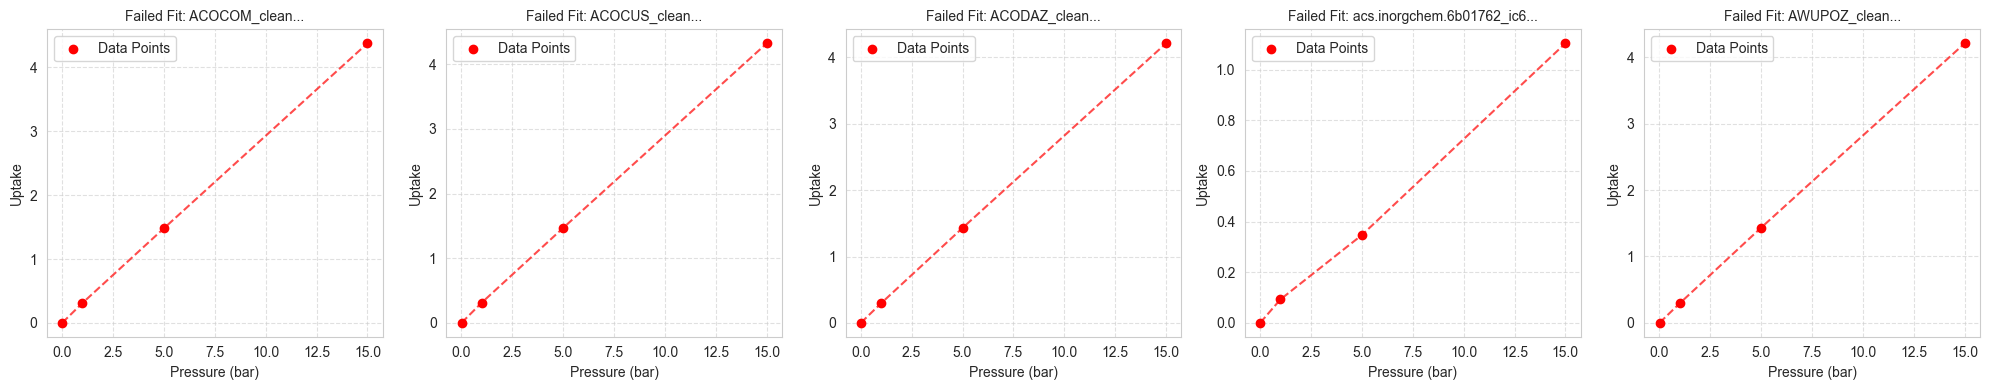

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path

# Sips 모델 함수 (사용자 정의 함수)
def sips(P, K1, K2, K3):
    P = np.asarray(P)
    PK3 = P**K3
    return (K1 * K2 * PK3) / (1 + K2 * PK3)

# ==============================================================================
# 섹션 1: 데이터 준비 및 병합
# ==============================================================================

print("Step 1: Preparing and merging uptake data...")

# ---- 원본 데이터 로딩 ----
try:
    UPTAKE_LIST_0_01 = pd.read_csv("../try15_Ar313_0.01_15bar_Isotherm/Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
    UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(1, 0.05, 'time_below_50_313_1') # ml_pressure를 경로에 맞게 수정
    UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(5, 0.05, '5bar_AR_313_CORE')
    UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15, 0.05, '15bar_AR_313_CORE')
except FileNotFoundError as e:
    print(f"Error loading initial data: {e}")
    print("Please check if the data files exist at the specified paths.")
    # 스크립트 실행을 중단하거나, 빈 데이터프레임으로 대체할 수 있습니다.
    raise

# ---- 데이터 병합 및 정제 ----
uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
df_isotherm_data = pd.concat(dfs_to_merge, axis=1)

print(f"Data shape before cleaning: {df_isotherm_data.shape}")
df_isotherm_data_clean = df_isotherm_data.dropna()
print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
print("-" * 30)

# ==============================================================================
# 섹션 2: Sips 등온선 피팅 및 결과 분석
# ==============================================================================

print("\nStep 2: Fitting Sips isotherm model for each MOF...")

P_data = np.array([0.01, 1.0, 5.0, 15.0])
sips_params_dict = {}
successful_fits = 0
failed_fits = 0
failed_mofs = []  # ❗ 실패한 MOF 이름을 저장할 리스트

iterator = tqdm(df_isotherm_data_clean.iterrows(),
                total=len(df_isotherm_data_clean),
                desc="⚙️  Fitting Sips Model")

for mof_name, row in iterator:
    q_data = row.values
    try:
        popt, pcov = curve_fit(
            sips,
            P_data,
            q_data,
            bounds=(0, np.inf),
            p0=[np.max(q_data), 0.1, 1.0]
        )
        sips_params_dict[mof_name] = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
        successful_fits += 1
    except RuntimeError:
        failed_fits += 1
        failed_mofs.append(mof_name)  # ❗ 실패 시 MOF 이름 저장

print("-" * 30)
print(f"\n✅ Sips model fitting process complete.")
print(f"  - ✔️ Successful fits: {successful_fits}")
print(f"  - ❌ Failed fits:     {failed_fits}")
print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
print("-" * 30)

print("\nHere are some example fitted parameters from successful fits:")
for i, (mof, params) in enumerate(sips_params_dict.items()):
    if i >= 5:
        break
    print(f"  - {mof}: K1={params['K1']:.4f}, K2={params['K2']:.4f}, K3={params['K3']:.4f}")

# ==============================================================================
# 섹션 3: 실패 원인 진단을 위한 시각화
# ==============================================================================

if failed_mofs:
    print(f"\n🔬 Visualizing some of the failed fits ({len(failed_mofs)} total)...")
    num_to_plot = min(len(failed_mofs), 5)
    
    fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
    axes = axes.flatten() # 2D 배열을 1D로 만듦

    for i in range(num_to_plot):
        mof_to_plot = failed_mofs[i]
        q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
        
        ax = axes[i]
        ax.scatter(P_data, q_data_failed, color='red', zorder=5, label='Data Points')
        ax.plot(P_data, q_data_failed, 'r--', alpha=0.7)
        ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
        ax.set_xlabel("Pressure (bar)")
        ax.set_ylabel("Uptake")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
    plt.tight_layout()
    plt.show()
else:
    print("\n🎉 No failed fits to visualize!")

Step 1: Preparing and merging uptake data...
Data shape before cleaning: (7760, 4)
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting Sips isotherm model for each MOF (in parallel)...


  0%|          | 0/7760 [00:00<?, ?it/s]

------------------------------

✅ Sips model fitting process complete.
  - ✔️ Successful fits: 7668
  - ❌ Failed fits:     92
Total MOFs processed: 7760
------------------------------

Here are some example fitted parameters from successful fits:
  - 1499489-acs.cgd.6b01265_1499490_clean: K1=11.0905, K2=0.0444, K3=0.9706
  - ACOCOM_clean: K1=112144.6848, K2=0.0000, K3=0.9843
  - ACOCUS_clean: K1=98212.2198, K2=0.0000, K3=0.9791
  - acs.cgd.5b01554_VAGNUP1452791_clean: K1=4.0347, K2=0.0276, K3=1.0069
  - acs.chemmater.5b03723_cm5b03723_si_004_clean: K1=6.0820, K2=0.1285, K3=1.0723

🔬 Visualizing some of the failed fits (92 total)...


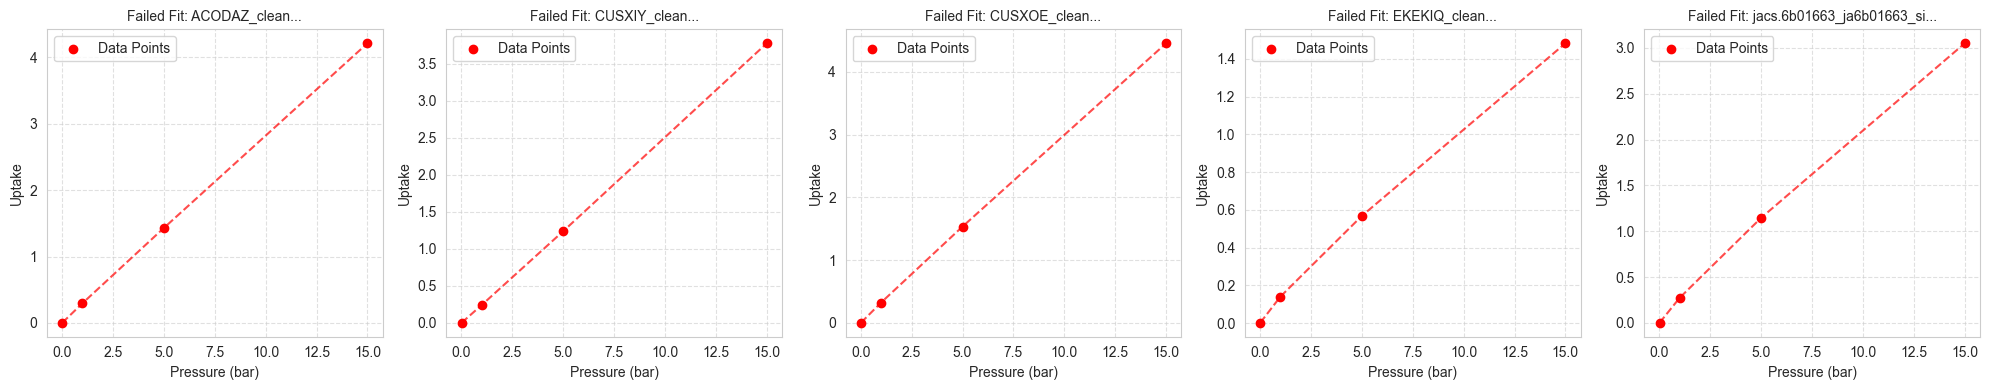

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path
from joblib import Parallel, delayed

# ==============================================================================
# 섹션 0: 핵심 함수 및 변수 정의
# ==============================================================================

# --- 경로 변수 ---
# CATBOOST_DIR 경로는 사용자 환경에 맞게 확인해주세요.
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/")

# --- Isotherm 모델 함수 ---
def sips(P, K1, K2, K3):
    """Sips 등온흡착식 모델"""
    P = np.asarray(P)
    PK3 = P**K3
    return (K1 * K2 * PK3) / (1 + K2 * PK3)

# --- 데이터 로딩 함수 ---
def Make_Uptake_list(ml_pressure, target_fraction, col):
    """
    지정된 압력과 분율에 대한 ML 결과를 읽어 Uptake 리스트를 생성합니다.
    (사용자가 제공한 함수)
    """
    if target_fraction != 1.0:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO{target_fraction}_QTFRAC_{target_fraction}'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        pred_df = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
        pred_mofs = set(pred_df['filename'])

        train_mofs_gcmc = set(train_df['filename']) - pred_mofs
        train_UPTAKES = train_df[train_df['filename'].isin(train_mofs_gcmc)][["filename", "Output"]]
        test_UPTAKES = pred_df[["filename", "y_pred"]]
        UPTAKE_LIST = pd.concat([train_UPTAKES.rename(columns={"Output": "Uptake"}), test_UPTAKES.rename(columns={"y_pred": "Uptake"})])
    else:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        UPTAKE_LIST = train_df[["filename", "Output"]].rename(columns={"Output": "Uptake"})

    if UPTAKE_LIST is None:
        print(f"Warning: No UPTAKE_LIST for RATIO {target_fraction} (Pressure: {ml_pressure} bar config). Skipping.")
        return pd.DataFrame(columns=['filename', 'Uptake']) # 실패 시 빈 DataFrame 반환
        
    return UPTAKE_LIST

# --- 병렬 처리를 위한 작업자 함수 ---
def fit_sips_for_mof(mof_name, q_data):
    """MOF 하나에 대해 Sips 모델을 피팅하고 결과를 반환합니다."""
    P_data = np.array([0.01, 1.0, 5.0, 15.0])
    try:
        popt, pcov = curve_fit(
            sips,
            P_data,
            q_data,
            bounds=(0, np.inf),
            p0=[np.max(q_data), 0.1, 1.0],
            maxfev=5000,
            ftol=1e-6,
            xtol=1e-6
        )
        params = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
        return (mof_name, params) # 성공 시 결과 반환
    except RuntimeError:
        return (mof_name, None) # 실패 시 None 반환

# ==============================================================================
# 메인 스크립트 실행 블록
# ==============================================================================
if __name__ == "__main__":

    # --- 섹션 1: 데이터 준비 및 병합 ---
    print("Step 1: Preparing and merging uptake data...")
    try:
        UPTAKE_LIST_0_01 = pd.read_csv(CATBOOST_DIR / "Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
        
        # ✅ 1bar 데이터는 ml_pressure=1 경로에서 로드하도록 수정됨
        UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(1, 0.05, 'time_below_50_3_13_1') 
        UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(5, 0.05, '5bar_AR_313_CORE')
        UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15, 0.05, '15bar_AR_313_CORE')

        uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
        uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
        uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
        uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

        dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
        df_isotherm_data = pd.concat(dfs_to_merge, axis=1)

        print(f"Data shape before cleaning: {df_isotherm_data.shape}")
        df_isotherm_data_clean = df_isotherm_data.dropna()
        print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
        print("-" * 30)

    except FileNotFoundError as e:
        print(f"\n❌ Error loading initial data: {e}")
        print("Please check if the data files exist at the specified paths.")
        exit() # 데이터 로딩 실패 시 스크립트 종료

    # --- 섹션 2: Sips 등온선 피팅 (병렬 처리) ---
    print("\nStep 2: Fitting Sips isotherm model for each MOF (in parallel)...")

    # n_jobs=-1: 모든 CPU 코어 사용
    results = Parallel(n_jobs=-1)(
        delayed(fit_sips_for_mof)(mof_name, row.values) 
        for mof_name, row in tqdm(df_isotherm_data_clean.iterrows(), total=len(df_isotherm_data_clean))
    )

    sips_params_dict = {}
    failed_mofs = []
    for mof_name, params in results:
        if params is not None:
            sips_params_dict[mof_name] = params
        else:
            failed_mofs.append(mof_name)

    successful_fits = len(sips_params_dict)
    failed_fits = len(failed_mofs)

    print("-" * 30)
    print(f"\n✅ Sips model fitting process complete.")
    print(f"  - ✔️ Successful fits: {successful_fits}")
    print(f"  - ❌ Failed fits:     {failed_fits}")
    print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
    print("-" * 30)

    print("\nHere are some example fitted parameters from successful fits:")
    for i, (mof, params) in enumerate(sips_params_dict.items()):
        if i >= 5:
            break
        print(f"  - {mof}: K1={params['K1']:.4f}, K2={params['K2']:.4f}, K3={params['K3']:.4f}")

    # --- 섹션 3: 실패 원인 진단을 위한 시각화 ---
    if failed_mofs:
        print(f"\n🔬 Visualizing some of the failed fits ({len(failed_mofs)} total)...")
        num_to_plot = min(len(failed_mofs), 5)
        
        fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
        axes = axes.flatten()

        for i in range(num_to_plot):
            mof_to_plot = failed_mofs[i]
            q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
            
            ax = axes[i]
            ax.scatter(np.array([0.01, 1.0, 5.0, 15.0]), q_data_failed, color='red', zorder=5, label='Data Points')
            ax.plot(np.array([0.01, 1.0, 5.0, 15.0]), q_data_failed, 'r--', alpha=0.7)
            ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
            ax.set_xlabel("Pressure (bar)")
            ax.set_ylabel("Uptake")
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend()
            
        plt.tight_layout()
        plt.show()
    else:
        print("\n🎉 No failed fits to visualize!")

Step 1: Preparing and merging uptake data...
Data shape before cleaning: (7760, 4)
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting Sips isotherm model for each MOF (in parallel)...


  0%|          | 0/7760 [00:00<?, ?it/s]

------------------------------

✅ Sips model fitting process complete.
  - ✔️ Successful fits: 7702
  - ❌ Failed fits:     58
Total MOFs processed: 7760
------------------------------

Here are some example fitted parameters from successful fits:
  - 1499489-acs.cgd.6b01265_1499490_clean: K1=11.4754, K2=0.0439, K3=0.9899
  - ACOCOM_clean: K1=112144.6848, K2=0.0000, K3=0.9843
  - ACOCUS_clean: K1=243.5338, K2=0.0013, K3=0.9887
  - acs.cgd.5b01554_VAGNUP1452791_clean: K1=13.3588, K2=0.0072, K3=0.9655
  - acs.chemmater.5b03723_cm5b03723_si_004_clean: K1=22.8250, K2=0.0236, K3=0.8023

🔬 Visualizing some of the failed fits (58 total)...


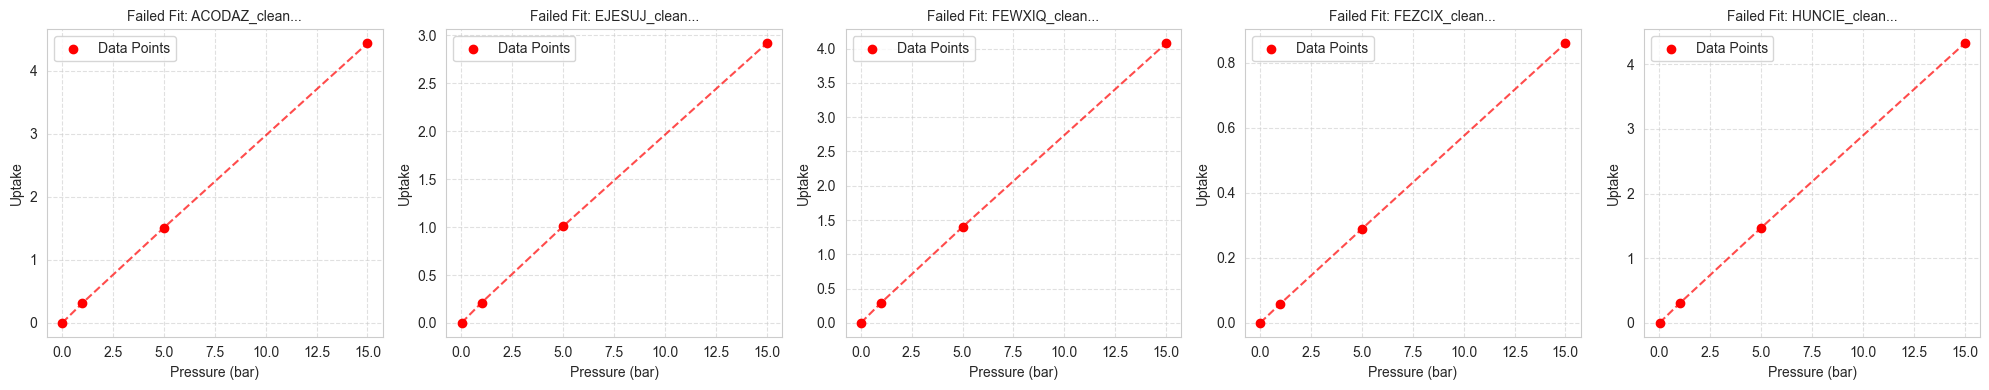

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path
from joblib import Parallel, delayed

# ==============================================================================
# 섹션 0: 핵심 함수 및 변수 정의
# ==============================================================================

# --- 경로 변수 ---
# CATBOOST_DIR 경로는 사용자 환경에 맞게 확인해주세요.
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/")

# --- Isotherm 모델 함수 ---
def sips(P, K1, K2, K3):
    """Sips 등온흡착식 모델"""
    P = np.asarray(P)
    PK3 = P**K3
    return (K1 * K2 * PK3) / (1 + K2 * PK3)

# --- 데이터 로딩 함수 ---
def Make_Uptake_list(ml_pressure, target_fraction, col):
    """
    지정된 압력과 분율에 대한 ML 결과를 읽어 Uptake 리스트를 생성합니다.
    (사용자가 제공한 함수)
    """
    if target_fraction != 1.0:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO{target_fraction}_QTFRAC_{target_fraction}'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        pred_df = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
        pred_mofs = set(pred_df['filename'])

        train_mofs_gcmc = set(train_df['filename']) - pred_mofs
        train_UPTAKES = train_df[train_df['filename'].isin(train_mofs_gcmc)][["filename", "Output"]]
        test_UPTAKES = pred_df[["filename", "y_pred"]]
        UPTAKE_LIST = pd.concat([train_UPTAKES.rename(columns={"Output": "Uptake"}), test_UPTAKES.rename(columns={"y_pred": "Uptake"})])
    else:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        UPTAKE_LIST = train_df[["filename", "Output"]].rename(columns={"Output": "Uptake"})

    if UPTAKE_LIST is None:
        print(f"Warning: No UPTAKE_LIST for RATIO {target_fraction} (Pressure: {ml_pressure} bar config). Skipping.")
        return pd.DataFrame(columns=['filename', 'Uptake']) # 실패 시 빈 DataFrame 반환
        
    return UPTAKE_LIST

# --- 병렬 처리를 위한 작업자 함수 ---
def fit_sips_for_mof(mof_name, q_data):
    """MOF 하나에 대해 Sips 모델을 피팅하고 결과를 반환합니다."""
    P_data = np.array([0.01, 1.0, 5.0, 15.0])
    try:
        popt, pcov = curve_fit(
            sips,
            P_data,
            q_data,
            bounds=(0, np.inf),
            p0=[np.max(q_data), 0.1, 1.0],
            maxfev=5000,
            ftol=1e-6,
            xtol=1e-6
        )
        params = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
        return (mof_name, params) # 성공 시 결과 반환
    except RuntimeError:
        return (mof_name, None) # 실패 시 None 반환

# ==============================================================================
# 메인 스크립트 실행 블록
# ==============================================================================
if __name__ == "__main__":

    # --- 섹션 1: 데이터 준비 및 병합 ---
    print("Step 1: Preparing and merging uptake data...")
    try:
        UPTAKE_LIST_0_01 = pd.read_csv(CATBOOST_DIR / "Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
        
        # ✅ 1bar 데이터는 ml_pressure=1 경로에서 로드하도록 수정됨
        UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(1, 1, 'time_below_50_3_13_1') 
        UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(5, 1, '5bar_AR_313_CORE')
        UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15, 1, '15bar_AR_313_CORE')

        uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
        uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
        uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
        uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

        dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
        df_isotherm_data = pd.concat(dfs_to_merge, axis=1)

        print(f"Data shape before cleaning: {df_isotherm_data.shape}")
        df_isotherm_data_clean = df_isotherm_data.dropna()
        print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
        print("-" * 30)

    except FileNotFoundError as e:
        print(f"\n❌ Error loading initial data: {e}")
        print("Please check if the data files exist at the specified paths.")
        exit() # 데이터 로딩 실패 시 스크립트 종료

    # --- 섹션 2: Sips 등온선 피팅 (병렬 처리) ---
    print("\nStep 2: Fitting Sips isotherm model for each MOF (in parallel)...")

    # n_jobs=-1: 모든 CPU 코어 사용
    results = Parallel(n_jobs=-1)(
        delayed(fit_sips_for_mof)(mof_name, row.values) 
        for mof_name, row in tqdm(df_isotherm_data_clean.iterrows(), total=len(df_isotherm_data_clean))
    )

    sips_params_dict = {}
    failed_mofs = []
    for mof_name, params in results:
        if params is not None:
            sips_params_dict[mof_name] = params
        else:
            failed_mofs.append(mof_name)

    successful_fits = len(sips_params_dict)
    failed_fits = len(failed_mofs)

    print("-" * 30)
    print(f"\n✅ Sips model fitting process complete.")
    print(f"  - ✔️ Successful fits: {successful_fits}")
    print(f"  - ❌ Failed fits:     {failed_fits}")
    print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
    print("-" * 30)

    print("\nHere are some example fitted parameters from successful fits:")
    for i, (mof, params) in enumerate(sips_params_dict.items()):
        if i >= 5:
            break
        print(f"  - {mof}: K1={params['K1']:.4f}, K2={params['K2']:.4f}, K3={params['K3']:.4f}")

    # --- 섹션 3: 실패 원인 진단을 위한 시각화 ---
    if failed_mofs:
        print(f"\n🔬 Visualizing some of the failed fits ({len(failed_mofs)} total)...")
        num_to_plot = min(len(failed_mofs), 5)
        
        fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
        axes = axes.flatten()

        for i in range(num_to_plot):
            mof_to_plot = failed_mofs[i]
            q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
            
            ax = axes[i]
            ax.scatter(np.array([0.01, 1.0, 5.0, 15.0]), q_data_failed, color='red', zorder=5, label='Data Points')
            ax.plot(np.array([0.01, 1.0, 5.0, 15.0]), q_data_failed, 'r--', alpha=0.7)
            ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
            ax.set_xlabel("Pressure (bar)")
            ax.set_ylabel("Uptake")
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend()
            
        plt.tight_layout()
        plt.show()
    else:
        print("\n🎉 No failed fits to visualize!")

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path
from joblib import Parallel, delayed

# ==============================================================================
# 섹션 0: 핵심 함수 및 변수 정의
# ==============================================================================

# --- 경로 변수 ---
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/")

# --- Isotherm 모델 함수 ---
def sips(P, K1, K2, K3):
    """Sips 등온흡착식 모델"""
    P = np.asarray(P)
    PK3 = P**K3
    return (K1 * K2 * PK3) / (1 + K2 * PK3)

def langmuir(P, K1, K2):
    """Langmuir 등온흡착식 모델"""
    return (K1 * K2 * P) / (1 + K2 * P)

# --- 데이터 로딩 함수 ---
def Make_Uptake_list(ml_pressure, target_fraction, col):
    """지정된 압력과 분율에 대한 ML 결과를 읽어 Uptake 리스트를 생성합니다."""
    # (이 함수는 기존과 동일하게 유지)
    if target_fraction != 1.0:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO{target_fraction}_QTFRAC_{target_fraction}'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        pred_df = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
        pred_mofs = set(pred_df['filename'])
        train_mofs_gcmc = set(train_df['filename']) - pred_mofs
        train_UPTAKES = train_df[train_df['filename'].isin(train_mofs_gcmc)][["filename", "Output"]]
        test_UPTAKES = pred_df[["filename", "y_pred"]]
        UPTAKE_LIST = pd.concat([train_UPTAKES.rename(columns={"Output": "Uptake"}), test_UPTAKES.rename(columns={"y_pred": "Uptake"})])
    else:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        UPTAKE_LIST = train_df[["filename", "Output"]].rename(columns={"Output": "Uptake"})
    if UPTAKE_LIST is None:
        print(f"Warning: No UPTAKE_LIST for RATIO {target_fraction} (Pressure: {ml_pressure} bar config). Skipping.")
        return pd.DataFrame(columns=['filename', 'Uptake'])
    return UPTAKE_LIST

# --- 병렬 처리를 위한 작업자 함수 (Sips -> Langmuir 순차 시도) ---
def fit_isotherm_models(mof_name, q_data):
    """MOF 하나에 대해 Sips, Langmuir 모델 순서로 피팅을 시도하고 결과를 반환합니다."""
    P_data = np.array([0.01, 1.0, 5.0, 15.0])
    
    # 1. Sips 모델 먼저 시도
    try:
        popt, pcov = curve_fit(sips, P_data, q_data, bounds=(0, np.inf), p0=[np.max(q_data), 0.1, 1.0], maxfev=5000, ftol=1e-6, xtol=1e-6)
        params = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
        return (mof_name, 'Sips', params) # 성공 시 모델 이름과 함께 반환
    except RuntimeError:
        # 2. Sips 실패 시 Langmuir 모델 시도
        try:
            popt, pcov = curve_fit(langmuir, P_data, q_data, bounds=(0, np.inf), p0=[np.max(q_data), 0.1], maxfev=5000, ftol=1e-6, xtol=1e-6)
            params = {'K1': popt[0], 'K2': popt[1]}
            return (mof_name, 'Langmuir', params) # 성공 시 모델 이름과 함께 반환
        except RuntimeError:
            # 3. 두 모델 모두 실패
            return (mof_name, 'Failed', None)

# ==============================================================================
# 메인 스크립트 실행 블록
# ==============================================================================
if __name__ == "__main__":

    # --- 섹션 1: 데이터 준비 및 병합 (기존과 동일) ---
    print("Step 1: Preparing and merging uptake data...")
    try:
        UPTAKE_LIST_0_01 = pd.read_csv(CATBOOST_DIR / "Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
        UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(1, 1.0, 'time_below_50_3_13_1')
        UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(5, 1.0, '5bar_AR_313_CORE')
        UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15, 1.0, '15bar_AR_313_CORE')
        
        uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
        uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
        uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
        uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

        dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
        df_isotherm_data = pd.concat(dfs_to_merge, axis=1)

        print(f"Data shape before cleaning: {df_isotherm_data.shape}")
        df_isotherm_data_clean = df_isotherm_data.dropna()
        print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
        print("-" * 30)
    except FileNotFoundError as e:
        print(f"\n❌ Error loading initial data: {e}")
        exit()

    # --- 섹션 2: 등온선 피팅 (병렬 처리, Sips->Langmuir) ---
    print("\nStep 2: Fitting isotherm models for each MOF (Sips -> Langmuir fallback)...")
    results = Parallel(n_jobs=-1)(
        delayed(fit_isotherm_models)(mof_name, row.values) 
        for mof_name, row in tqdm(df_isotherm_data_clean.iterrows(), total=len(df_isotherm_data_clean))
    )

    # --- 결과 정리 (모델별로 구분) ---
    sips_params_dict = {}
    langmuir_params_dict = {}
    failed_mofs = []
    for mof_name, model_name, params in results:
        if model_name == 'Sips':
            sips_params_dict[mof_name] = params
        elif model_name == 'Langmuir':
            langmuir_params_dict[mof_name] = params
        else:
            failed_mofs.append(mof_name)

    # --- 최종 피팅 결과 요약 리포트 (업데이트) ---
    print("-" * 30)
    print(f"\n✅ Isotherm model fitting process complete.")
    print(f"  - ✔️ Sips fits:     {len(sips_params_dict)}")
    print(f"  - ✔️ Langmuir fits: {len(langmuir_params_dict)} (Sips failed, Langmuir succeeded)")
    print(f"  - ❌ Total Failed:  {len(failed_mofs)} (Both models failed)")
    print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
    print("-" * 30)

    # --- 섹션 3: 실패 원인 진단을 위한 시각화 (기존과 동일) ---
    if failed_mofs:
        print(f"\n🔬 Visualizing some of the completely failed fits ({len(failed_mofs)} total)...")
        # (시각화 코드는 변경 없음)
        num_to_plot = min(len(failed_mofs), 5)
        fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
        axes = axes.flatten()
        for i in range(num_to_plot):
            mof_to_plot = failed_mofs[i]
            q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
            ax = axes[i]
            ax.scatter(np.array([0.01, 1.0, 5.0, 15.0]), q_data_failed, color='red', zorder=5, label='Data Points')
            ax.plot(np.array([0.01, 1.0, 5.0, 15.0]), q_data_failed, 'r--', alpha=0.7)
            ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
            ax.set_xlabel("Pressure (bar)")
            ax.set_ylabel("Uptake")
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("\n🎉 No fits failed for both models!")

Step 1: Preparing and merging uptake data...
Data shape before cleaning: (7760, 4)
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting isotherm models for each MOF (Sips -> Langmuir fallback)...


  0%|          | 0/7760 [00:00<?, ?it/s]

------------------------------

✅ Isotherm model fitting process complete.
  - ✔️ Sips fits:     7702
  - ✔️ Langmuir fits: 58 (Sips failed, Langmuir succeeded)
  - ❌ Total Failed:  0 (Both models failed)
Total MOFs processed: 7760
------------------------------

🎉 No fits failed for both models!


In [123]:
df_isotherm_data.reset_index()[df_isotherm_data.reset_index()["filename"] == "ACOCOM_clean"]

,filename,0.01bar,1bar,5bar,15bar
1,ACOCOM_clean,0.003168,0.311217,1.479258,4.37288


Step 1: Preparing and merging uptake data...
Data shape before cleaning: (7760, 4)
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting Sips isotherm model for each MOF...


⚙️  Fitting Sips Model:   0%|          | 0/7760 [00:00<?, ?it/s]

------------------------------

✅ Sips model fitting process complete.
  - ✔️ Successful fits: 7756
  - ❌ Failed fits:     4
Total MOFs processed: 7760
------------------------------

Here are some example fitted parameters from successful fits:
  - 1499489-acs.cgd.6b01265_1499490_clean: K1=3.3904, K2=41478699.7936, K3=5.2206
  - ACOCOM_clean: K1=3.4083, K2=28826286.5697, K3=5.2647
  - ACOCUS_clean: K1=3.2765, K2=31535323.8754, K3=5.2688
  - ACODAZ_clean: K1=3.1797, K2=27018678.6702, K3=5.2301
  - acs.cgd.5b01554_VAGNUP1452791_clean: K1=0.9460, K2=39108025.0323, K3=5.2871

🔬 Visualizing some of the failed fits (4 total)...


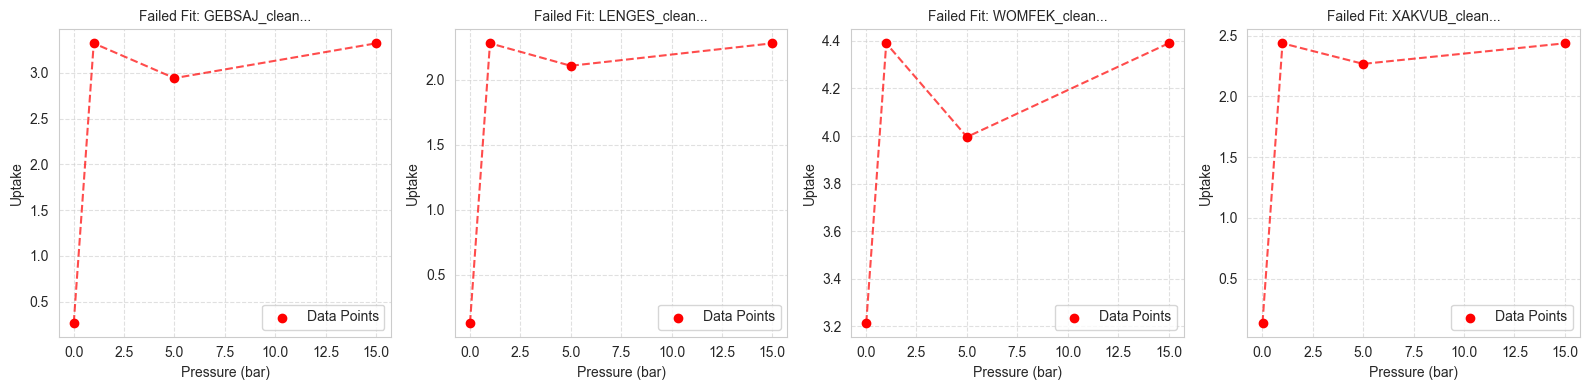

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path


print("Step 1: Preparing and merging uptake data...")

# ---- 원본 데이터 로딩 ----
try:
    UPTAKE_LIST_0_01 = pd.read_csv("../try15_Ar313_0.01_15bar_Isotherm/Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
    UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(15, 0.3, 'time_below_50_313_1') # ml_pressure를 경로에 맞게 수정
    UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(15, 0.3, '5bar_AR_313_CORE')
    UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15, 0.3, '15bar_AR_313_CORE')
except FileNotFoundError as e:
    print(f"Error loading initial data: {e}")
    print("Please check if the data files exist at the specified paths.")
    # 스크립트 실행을 중단하거나, 빈 데이터프레임으로 대체할 수 있습니다.
    raise

# ---- 데이터 병합 및 정제 ----
uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
df_isotherm_data = pd.concat(dfs_to_merge, axis=1)

print(f"Data shape before cleaning: {df_isotherm_data.shape}")
df_isotherm_data_clean = df_isotherm_data.dropna()
print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
print("-" * 30)

# ==============================================================================
# 섹션 2: Sips 등온선 피팅 및 결과 분석
# ==============================================================================

print("\nStep 2: Fitting Sips isotherm model for each MOF...")

P_data = np.array([0.01, 1.0, 5.0, 15.0])
sips_params_dict = {}
successful_fits = 0
failed_fits = 0
failed_mofs = []  # ❗ 실패한 MOF 이름을 저장할 리스트

iterator = tqdm(df_isotherm_data_clean.iterrows(),
                total=len(df_isotherm_data_clean),
                desc="⚙️  Fitting Sips Model")

for mof_name, row in iterator:
    q_data = row.values
    try:
        popt, pcov = curve_fit(
            sips,
            P_data,
            q_data,
            bounds=(0, np.inf),
            p0=[np.max(q_data), 0.1, 1.0]
        )
        sips_params_dict[mof_name] = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
        successful_fits += 1
    except RuntimeError:
        failed_fits += 1
        failed_mofs.append(mof_name)  # ❗ 실패 시 MOF 이름 저장

print("-" * 30)
print(f"\n✅ Sips model fitting process complete.")
print(f"  - ✔️ Successful fits: {successful_fits}")
print(f"  - ❌ Failed fits:     {failed_fits}")
print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
print("-" * 30)

print("\nHere are some example fitted parameters from successful fits:")
for i, (mof, params) in enumerate(sips_params_dict.items()):
    if i >= 5:
        break
    print(f"  - {mof}: K1={params['K1']:.4f}, K2={params['K2']:.4f}, K3={params['K3']:.4f}")

# ==============================================================================
# 섹션 3: 실패 원인 진단을 위한 시각화
# ==============================================================================

if failed_mofs:
    print(f"\n🔬 Visualizing some of the failed fits ({len(failed_mofs)} total)...")
    num_to_plot = min(len(failed_mofs), 5)
    
    fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
    axes = axes.flatten() # 2D 배열을 1D로 만듦

    for i in range(num_to_plot):
        mof_to_plot = failed_mofs[i]
        q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
        
        ax = axes[i]
        ax.scatter(P_data, q_data_failed, color='red', zorder=5, label='Data Points')
        ax.plot(P_data, q_data_failed, 'r--', alpha=0.7)
        ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
        ax.set_xlabel("Pressure (bar)")
        ax.set_ylabel("Uptake")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
    plt.tight_layout()
    plt.show()
else:
    print("\n🎉 No failed fits to visualize!")

Step 1: Preparing and merging uptake data...
Data shape before cleaning: (7760, 4)
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting Sips isotherm model for each MOF...


⚙️  Fitting Sips Model:   0%|          | 0/7760 [00:00<?, ?it/s]

------------------------------

✅ Sips model fitting process complete.
  - ✔️ Successful fits: 7755
  - ❌ Failed fits:     5
Total MOFs processed: 7760
------------------------------

Here are some example fitted parameters from successful fits:
  - 1499489-acs.cgd.6b01265_1499490_clean: K1=3.6698, K2=33743133.2915, K3=5.1942
  - ACOCOM_clean: K1=3.4083, K2=28826286.5697, K3=5.2647
  - ACOCUS_clean: K1=3.3283, K2=36744106.0804, K3=5.2937
  - ACODAZ_clean: K1=3.4625, K2=31033926.8724, K3=5.2783
  - acs.cgd.5b01554_VAGNUP1452791_clean: K1=0.9456, K2=35368949.0468, K3=5.2662

🔬 Visualizing some of the failed fits (5 total)...


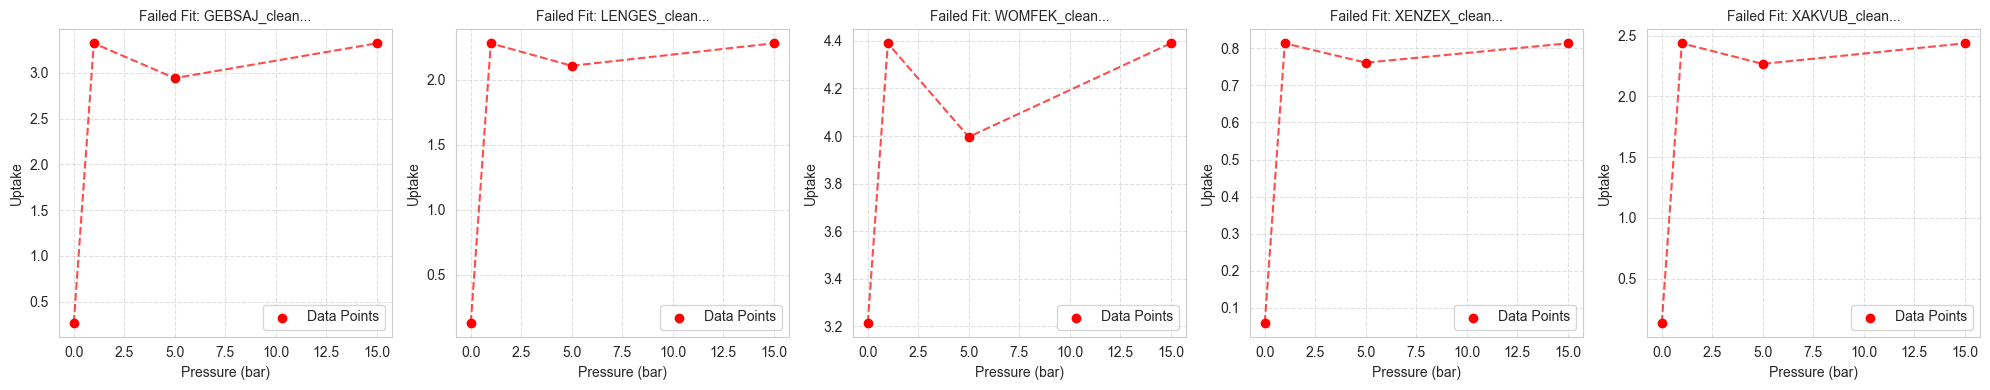

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path

print("Step 1: Preparing and merging uptake data...")

# ---- 원본 데이터 로딩 ----
try:
    UPTAKE_LIST_0_01 = pd.read_csv("../try15_Ar313_0.01_15bar_Isotherm/Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
    UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(15, 0.8, 'time_below_50_313_1') # ml_pressure를 경로에 맞게 수정
    UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(5, 0.8, '5bar_AR_313_CORE')
    UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15, 0.8, '15bar_AR_313_CORE')
except FileNotFoundError as e:
    print(f"Error loading initial data: {e}")
    print("Please check if the data files exist at the specified paths.")
    # 스크립트 실행을 중단하거나, 빈 데이터프레임으로 대체할 수 있습니다.
    raise

# ---- 데이터 병합 및 정제 ----
uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
df_isotherm_data = pd.concat(dfs_to_merge, axis=1)

print(f"Data shape before cleaning: {df_isotherm_data.shape}")
df_isotherm_data_clean = df_isotherm_data.dropna()
print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
print("-" * 30)

# ==============================================================================
# 섹션 2: Sips 등온선 피팅 및 결과 분석
# ==============================================================================

print("\nStep 2: Fitting Sips isotherm model for each MOF...")

P_data = np.array([0.01, 1.0, 5.0, 15.0])
sips_params_dict = {}
successful_fits = 0
failed_fits = 0
failed_mofs = []  # ❗ 실패한 MOF 이름을 저장할 리스트

iterator = tqdm(df_isotherm_data_clean.iterrows(),
                total=len(df_isotherm_data_clean),
                desc="⚙️  Fitting Sips Model")

for mof_name, row in iterator:
    q_data = row.values
    try:
        popt, pcov = curve_fit(
            sips,
            P_data,
            q_data,
            bounds=(0, np.inf),
            p0=[np.max(q_data), 0.1, 1.0]
        )
        sips_params_dict[mof_name] = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
        successful_fits += 1
    except RuntimeError:
        failed_fits += 1
        failed_mofs.append(mof_name)  # ❗ 실패 시 MOF 이름 저장

print("-" * 30)
print(f"\n✅ Sips model fitting process complete.")
print(f"  - ✔️ Successful fits: {successful_fits}")
print(f"  - ❌ Failed fits:     {failed_fits}")
print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
print("-" * 30)

print("\nHere are some example fitted parameters from successful fits:")
for i, (mof, params) in enumerate(sips_params_dict.items()):
    if i >= 5:
        break
    print(f"  - {mof}: K1={params['K1']:.4f}, K2={params['K2']:.4f}, K3={params['K3']:.4f}")

# ==============================================================================
# 섹션 3: 실패 원인 진단을 위한 시각화
# ==============================================================================

if failed_mofs:
    print(f"\n🔬 Visualizing some of the failed fits ({len(failed_mofs)} total)...")
    num_to_plot = min(len(failed_mofs), 5)
    
    fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
    axes = axes.flatten() # 2D 배열을 1D로 만듦

    for i in range(num_to_plot):
        mof_to_plot = failed_mofs[i]
        q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
        
        ax = axes[i]
        ax.scatter(P_data, q_data_failed, color='red', zorder=5, label='Data Points')
        ax.plot(P_data, q_data_failed, 'r--', alpha=0.7)
        ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
        ax.set_xlabel("Pressure (bar)")
        ax.set_ylabel("Uptake")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
    plt.tight_layout()
    plt.show()
else:
    print("\n🎉 No failed fits to visualize!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path
# ==============================================================================
# 섹션 1: 데이터 준비 및 병합
# ==============================================================================

print("Step 1: Preparing and merging uptake data...")

# ---- 원본 데이터 로딩 ----
try:
    UPTAKE_LIST_0_01 = pd.read_csv("../try15_Ar313_0.01_15bar_Isotherm/Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
    UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(15, 1, 'time_below_50_313_1') # ml_pressure를 경로에 맞게 수정
    UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(15, 1, '5bar_AR_313_CORE')
    UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15, 1, '15bar_AR_313_CORE')
except FileNotFoundError as e:
    print(f"Error loading initial data: {e}")
    print("Please check if the data files exist at the specified paths.")
    # 스크립트 실행을 중단하거나, 빈 데이터프레임으로 대체할 수 있습니다.
    raise

# ---- 데이터 병합 및 정제 ----
uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
df_isotherm_data = pd.concat(dfs_to_merge, axis=1)
df_isotherm_data
# print(f"Data shape before cleaning: {df_isotherm_data.shape}")
# df_isotherm_data_clean = df_isotherm_data.dropna()
# print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
# print("-" * 30)

# # ==============================================================================
# # 섹션 2: Sips 등온선 피팅 및 결과 분석
# # ==============================================================================

# print("\nStep 2: Fitting Sips isotherm model for each MOF...")

# P_data = np.array([0.01, 1.0, 5.0, 15.0])
# sips_params_dict = {}
# successful_fits = 0
# failed_fits = 0
# failed_mofs = []  # ❗ 실패한 MOF 이름을 저장할 리스트

# iterator = tqdm(df_isotherm_data_clean.iterrows(),
#                 total=len(df_isotherm_data_clean),
#                 desc="⚙️  Fitting Sips Model")

# for mof_name, row in iterator:
#     q_data = row.values
#     try:
#         popt, pcov = curve_fit(
#             sips,
#             P_data,
#             q_data,
#             bounds=(0, np.inf),
#             p0=[np.max(q_data), 0.1, 1.0]
#         )
#         sips_params_dict[mof_name] = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
#         successful_fits += 1
#     except RuntimeError:
#         failed_fits += 1
#         failed_mofs.append(mof_name)  # ❗ 실패 시 MOF 이름 저장

# print("-" * 30)
# print(f"\n✅ Sips model fitting process complete.")
# print(f"  - ✔️ Successful fits: {successful_fits}")
# print(f"  - ❌ Failed fits:     {failed_fits}")
# print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
# print("-" * 30)

# print("\nHere are some example fitted parameters from successful fits:")
# for i, (mof, params) in enumerate(sips_params_dict.items()):
#     if i >= 5:
#         break
#     print(f"  - {mof}: K1={params['K1']:.4f}, K2={params['K2']:.4f}, K3={params['K3']:.4f}")

# # ==============================================================================
# # 섹션 3: 실패 원인 진단을 위한 시각화
# # ==============================================================================

# if failed_mofs:
#     print(f"\n🔬 Visualizing some of the failed fits ({len(failed_mofs)} total)...")
#     num_to_plot = min(len(failed_mofs), 5)
    
#     fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
#     axes = axes.flatten() # 2D 배열을 1D로 만듦

#     for i in range(num_to_plot):
#         mof_to_plot = failed_mofs[i]
#         q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
        
#         ax = axes[i]
#         ax.scatter(P_data, q_data_failed, color='red', zorder=5, label='Data Points')
#         ax.plot(P_data, q_data_failed, 'r--', alpha=0.7)
#         ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
#         ax.set_xlabel("Pressure (bar)")
#         ax.set_ylabel("Uptake")
#         ax.grid(True, linestyle='--', alpha=0.6)
#         ax.legend()
        
#     plt.tight_layout()
#     plt.show()
# else:
#     print("\n🎉 No failed fits to visualize!")

Step 1: Preparing and merging uptake data...


,0.01bar,1bar,5bar,15bar
filename,,,,
1499489-acs.cgd.6b01265_1499490_clean,0.005118,4.484627,2.040043,4.484627
ACOCOM_clean,0.003168,4.372880,1.479258,4.372880
ACOCUS_clean,0.003187,4.483099,1.531660,4.483099
ACODAZ_clean,0.003023,4.438173,1.511265,4.438173
acs.cgd.5b01554_VAGNUP1452791_clean,0.001002,1.198039,0.440603,1.198039
...,...,...,...,...
ZUTBIB_clean,0.018200,3.567563,2.573831,3.567563
ZUTBUN_clean,0.024938,3.584226,2.876449,3.584226
ZUWXUM_clean,0.004375,4.816205,1.978073,4.816205


In [119]:
DD = df_isotherm_data.reset_index()
DD[DD["filename"] == 'GEBSAJ_clean']
# df_isotherm_data
uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
uptake_1[uptake_1["filename"] == 'GEBSAJ_clean']


,filename,1bar
299,GEBSAJ_clean,3.320647


In [106]:
UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(1, 1, 'time_below_50_313_1')
UPTAKE_LIST_1bar_0_05[UPTAKE_LIST_1bar_0_05["filename"] == "GEBSAJ_clean"]

,filename,Uptake
299,GEBSAJ_clean,2.370711


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path

# ==============================================================================
# 섹션 0: 필요한 함수 및 변수 정의 (기존 코드)
# 이 부분은 이미 사용자 환경에 정의되어 있다고 가정합니다.
# ==============================================================================

# 예시 데이터 로딩 함수 (사용자 정의 함수)
def Make_Uptake_list(ml_pressure, target_fraction, col):
    # 이 함수는 사용자가 제공한 원본 코드에 따라 구현되어야 합니다.
    # 아래는 함수의 동작을 모방한 임시 코드입니다.
    # 실제 사용 시에는 이 부분을 사용자의 원본 함수로 교체해야 합니다.
    try:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO{target_fraction}_QTFRAC_{target_fraction}'
        base_path = Path("../try15_Ar313_0.01_15bar_Isotherm/") / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        pred_df = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
        pred_mofs = set(pred_df['filename'])
        train_mofs_gcmc = set(train_df['filename']) - pred_mofs
        train_UPTAKES = train_df[train_df['filename'].isin(train_mofs_gcmc)][["filename", "Output"]]
        test_UPTAKES = pred_df[["filename", "y_pred"]]
        UPTAKE_LIST = pd.concat([train_UPTAKES.rename(columns={"Output": "Uptake"}), test_UPTAKES.rename(columns={"y_pred": "Uptake"})])
        return UPTAKE_LIST
    except FileNotFoundError:
        print(f"Warning: Data for pressure {ml_pressure}, fraction {target_fraction} not found. Returning empty DataFrame.")
        return pd.DataFrame(columns=['filename', 'Uptake'])


# Sips 모델 함수 (사용자 정의 함수)
def sips(P, K1, K2, K3):
    P = np.asarray(P)
    PK3 = P**K3
    return (K1 * K2 * PK3) / (1 + K2 * PK3)

# ==============================================================================
# 섹션 1: 데이터 준비 및 병합
# ==============================================================================

print("Step 1: Preparing and merging uptake data...")

# ---- 원본 데이터 로딩 ----
try:
    UPTAKE_LIST_0_01 = pd.read_csv("../try15_Ar313_0.01_15bar_Isotherm/Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
    UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(15, 0.05, 'time_below_50_313_1') # ml_pressure를 경로에 맞게 수정
    UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(5, 0.05, '5bar_AR_313_CORE')
    UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15, 0.05, '15bar_AR_313_CORE')
except FileNotFoundError as e:
    print(f"Error loading initial data: {e}")
    print("Please check if the data files exist at the specified paths.")
    # 스크립트 실행을 중단하거나, 빈 데이터프레임으로 대체할 수 있습니다.
    raise

# ---- 데이터 병합 및 정제 ----
uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
df_isotherm_data = pd.concat(dfs_to_merge, axis=1)

print(f"Data shape before cleaning: {df_isotherm_data.shape}")
df_isotherm_data_clean = df_isotherm_data.dropna()
print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
print("-" * 30)

# ==============================================================================
# 섹션 2: Sips 등온선 피팅 및 결과 분석
# ==============================================================================

print("\nStep 2: Fitting Sips isotherm model for each MOF...")

P_data = np.array([0.01, 1.0, 5.0, 15.0])
sips_params_dict = {}
successful_fits = 0
failed_fits = 0
failed_mofs = []  # ❗ 실패한 MOF 이름을 저장할 리스트

iterator = tqdm(df_isotherm_data_clean.iterrows(),
                total=len(df_isotherm_data_clean),
                desc="⚙️  Fitting Sips Model")

for mof_name, row in iterator:
    q_data = row.values
    try:
        popt, pcov = curve_fit(
            sips,
            P_data,
            q_data,
            bounds=(0, np.inf),
            p0=[np.max(q_data), 0.1, 1.0],
            maxfev=5000,      # 최대 계산 횟수를 5000번으로 늘림
            ftol=1e-6,        # 허용 오차 기준을 덜 엄격하게 설정
            xtol=1e-6
        )
        sips_params_dict[mof_name] = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
        successful_fits += 1
    except RuntimeError:
        failed_fits += 1
        failed_mofs.append(mof_name)  # ❗ 실패 시 MOF 이름 저장

print("-" * 30)
print(f"\n✅ Sips model fitting process complete.")
print(f"  - ✔️ Successful fits: {successful_fits}")
print(f"  - ❌ Failed fits:     {failed_fits}")
print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
print("-" * 30)

print("\nHere are some example fitted parameters from successful fits:")
for i, (mof, params) in enumerate(sips_params_dict.items()):
    if i >= 5:
        break
    print(f"  - {mof}: K1={params['K1']:.4f}, K2={params['K2']:.4f}, K3={params['K3']:.4f}")

# ==============================================================================
# 섹션 3: 실패 원인 진단을 위한 시각화
# ==============================================================================

if failed_mofs:
    print(f"\n🔬 Visualizing some of the failed fits ({len(failed_mofs)} total)...")
    num_to_plot = min(len(failed_mofs), 5)
    
    fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
    axes = axes.flatten() # 2D 배열을 1D로 만듦

    for i in range(num_to_plot):
        mof_to_plot = failed_mofs[i]
        q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
        
        ax = axes[i]
        ax.scatter(P_data, q_data_failed, color='red', zorder=5, label='Data Points')
        ax.plot(P_data, q_data_failed, 'r--', alpha=0.7)
        ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
        ax.set_xlabel("Pressure (bar)")
        ax.set_ylabel("Uptake")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
    plt.tight_layout()
    plt.show()
else:
    print("\n🎉 No failed fits to visualize!")

Step 1: Preparing and merging uptake data...
Data shape before cleaning: (7760, 4)
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting Sips isotherm model for each MOF...


⚙️  Fitting Sips Model:   0%|          | 0/7760 [00:00<?, ?it/s]

------------------------------

✅ Sips model fitting process complete.
  - ✔️ Successful fits: 7760
  - ❌ Failed fits:     0
Total MOFs processed: 7760
------------------------------

Here are some example fitted parameters from successful fits:
  - 1499489-acs.cgd.6b01265_1499490_clean: K1=3.4607, K2=604456.0367, K3=4.3131
  - ACOCOM_clean: K1=3.4083, K2=597289.5429, K3=4.4122
  - ACOCUS_clean: K1=3.3720, K2=581753.4720, K3=4.4029
  - ACODAZ_clean: K1=3.2830, K2=567262.1758, K3=4.4031
  - acs.cgd.5b01554_VAGNUP1452791_clean: K1=0.9624, K2=832071.9082, K3=4.4594

🎉 No failed fits to visualize!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path

# ==============================================================================
# 섹션 0: 필요한 함수 및 변수 정의 (기존 코드)
# 이 부분은 이미 사용자 환경에 정의되어 있다고 가정합니다.
# ==============================================================================

# 예시 데이터 로딩 함수 (사용자 정의 함수)
def Make_Uptake_list(ml_pressure, target_fraction, col):
    # 이 함수는 사용자가 제공한 원본 코드에 따라 구현되어야 합니다.
    # 아래는 함수의 동작을 모방한 임시 코드입니다.
    # 실제 사용 시에는 이 부분을 사용자의 원본 함수로 교체해야 합니다.
    try:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO{target_fraction}_QTFRAC_{target_fraction}'
        base_path = Path("../try15_Ar313_0.01_15bar_Isotherm/") / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        pred_df = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
        pred_mofs = set(pred_df['filename'])
        train_mofs_gcmc = set(train_df['filename']) - pred_mofs
        train_UPTAKES = train_df[train_df['filename'].isin(train_mofs_gcmc)][["filename", "Output"]]
        test_UPTAKES = pred_df[["filename", "y_pred"]]
        UPTAKE_LIST = pd.concat([train_UPTAKES.rename(columns={"Output": "Uptake"}), test_UPTAKES.rename(columns={"y_pred": "Uptake"})])
        return UPTAKE_LIST
    except FileNotFoundError:
        print(f"Warning: Data for pressure {ml_pressure}, fraction {target_fraction} not found. Returning empty DataFrame.")
        return pd.DataFrame(columns=['filename', 'Uptake'])


# Sips 모델 함수 (사용자 정의 함수)
def sips(P, K1, K2, K3):
    P = np.asarray(P)
    PK3 = P**K3
    return (K1 * K2 * PK3) / (1 + K2 * PK3)

# ==============================================================================
# 섹션 1: 데이터 준비 및 병합
# ==============================================================================

print("Step 1: Preparing and merging uptake data...")

# ---- 원본 데이터 로딩 ----
try:
    UPTAKE_LIST_0_01 = pd.read_csv("../try15_Ar313_0.01_15bar_Isotherm/Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
    UPTAKE_LIST_1bar_0_05 = Make_Uptake_list(15, 0.3 , 'time_below_50_313_1') # ml_pressure를 경로에 맞게 수정
    UPTAKE_LIST_5bar_0_05 = Make_Uptake_list(5,  0.3 , '5bar_AR_313_CORE')
    UPTAKE_LIST_15bar_0_05 = Make_Uptake_list(15,  0.3,  '15bar_AR_313_CORE')
except FileNotFoundError as e:
    print(f"Error loading initial data: {e}")
    print("Please check if the data files exist at the specified paths.")
    # 스크립트 실행을 중단하거나, 빈 데이터프레임으로 대체할 수 있습니다.
    raise

# ---- 데이터 병합 및 정제 ----
uptake_0_01 = UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"})
uptake_1 = UPTAKE_LIST_1bar_0_05.rename(columns={"Uptake": "1bar"})
uptake_5 = UPTAKE_LIST_5bar_0_05.rename(columns={"Uptake": "5bar"})
uptake_15 = UPTAKE_LIST_15bar_0_05.rename(columns={"Uptake": "15bar"})

dfs_to_merge = [df.set_index('filename') for df in [uptake_0_01, uptake_1, uptake_5, uptake_15]]
df_isotherm_data = pd.concat(dfs_to_merge, axis=1)

print(f"Data shape before cleaning: {df_isotherm_data.shape}")
df_isotherm_data_clean = df_isotherm_data.dropna()
print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
print("-" * 30)

# ==============================================================================
# 섹션 2: Sips 등온선 피팅 및 결과 분석
# ==============================================================================

print("\nStep 2: Fitting Sips isotherm model for each MOF...")

P_data = np.array([0.01, 1.0, 5.0, 15.0])
sips_params_dict = {}
successful_fits = 0
failed_fits = 0
failed_mofs = []  # ❗ 실패한 MOF 이름을 저장할 리스트

iterator = tqdm(df_isotherm_data_clean.iterrows(),
                total=len(df_isotherm_data_clean),
                desc="⚙️  Fitting Sips Model")

for mof_name, row in iterator:
    q_data = row.values
    try:
        popt, pcov = curve_fit(
            sips,
            P_data,
            q_data,
            bounds=(0, np.inf),
            p0=[np.max(q_data), 0.1, 1.0],
            maxfev=5000,      # 최대 계산 횟수를 5000번으로 늘림
            ftol=1e-6,        # 허용 오차 기준을 덜 엄격하게 설정
            xtol=1e-6
        )
        sips_params_dict[mof_name] = {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]}
        successful_fits += 1
    except RuntimeError:
        failed_fits += 1
        failed_mofs.append(mof_name)  # ❗ 실패 시 MOF 이름 저장

print("-" * 30)
print(f"\n✅ Sips model fitting process complete.")
print(f"  - ✔️ Successful fits: {successful_fits}")
print(f"  - ❌ Failed fits:     {failed_fits}")
print(f"Total MOFs processed: {len(df_isotherm_data_clean)}")
print("-" * 30)

print("\nHere are some example fitted parameters from successful fits:")
for i, (mof, params) in enumerate(sips_params_dict.items()):
    if i >= 5:
        break
    print(f"  - {mof}: K1={params['K1']:.4f}, K2={params['K2']:.4f}, K3={params['K3']:.4f}")

# ==============================================================================
# 섹션 3: 실패 원인 진단을 위한 시각화
# ==============================================================================
if failed_mofs:
    print(f"\n🔬 Visualizing some of the failed fits ({len(failed_mofs)} total)...")
    num_to_plot = min(len(failed_mofs), 5)
    
    fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
    axes = axes.flatten() # 2D 배열을 1D로 만듦

    for i in range(num_to_plot):
        mof_to_plot = failed_mofs[i]
        q_data_failed = df_isotherm_data_clean.loc[mof_to_plot].values
        
        ax = axes[i]
        ax.scatter(P_data, q_data_failed, color='red', zorder=5, label='Data Points')
        ax.plot(P_data, q_data_failed, 'r--', alpha=0.7)
        ax.set_title(f"Failed Fit: {mof_to_plot[:25]}...", fontsize=10)
        ax.set_xlabel("Pressure (bar)")
        ax.set_ylabel("Uptake")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        
    plt.tight_layout()
    plt.show()
else:
    print("\n🎉 No failed fits to visualize!")

Step 1: Preparing and merging uptake data...
Data shape before cleaning: (7760, 4)
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting Sips isotherm model for each MOF...


⚙️  Fitting Sips Model:   0%|          | 0/7760 [00:00<?, ?it/s]

------------------------------

✅ Sips model fitting process complete.
  - ✔️ Successful fits: 7760
  - ❌ Failed fits:     0
Total MOFs processed: 7760
------------------------------

Here are some example fitted parameters from successful fits:
  - 1499489-acs.cgd.6b01265_1499490_clean: K1=3.3904, K2=595051.4936, K3=4.3052
  - ACOCOM_clean: K1=3.4083, K2=597289.5429, K3=4.4122
  - ACOCUS_clean: K1=3.2765, K2=563127.4157, K3=4.3897
  - ACODAZ_clean: K1=3.1797, K2=548599.3558, K3=4.3891
  - acs.cgd.5b01554_VAGNUP1452791_clean: K1=0.9460, K2=827210.1420, K3=4.4545

🎉 No failed fits to visualize!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from pathlib import Path
from joblib import Parallel, delayed

# ==============================================================================
# 섹션 0: 핵심 함수 및 변수 정의 (스크립트 최상단에 위치)
# ==============================================================================

# --- 경로 변수 ---
CATBOOST_DIR = Path("../try15_Ar313_0.01_15bar_Isotherm/")

# --- Isotherm 모델 함수 ---
def sips(P, K1, K2, K3):
    """Sips 등온흡착식 모델"""
    P = np.asarray(P)
    PK3 = P**K3
    return (K1 * K2 * PK3) / (1 + K2 * PK3)

def langmuir(P, K1, K2):
    """Langmuir 등온흡착식 모델"""
    return (K1 * K2 * P) / (1 + K2 * P)

# --- 데이터 로딩 함수 ---
def Make_Uptake_list(ml_pressure, target_fraction, col):
    """지정된 압력과 분율에 대한 ML 결과를 읽어 Uptake 리스트를 생성합니다."""
    if target_fraction != 1.0:
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO{target_fraction}_QTFRAC_{target_fraction}'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        pred_df = pd.read_csv(base_path / 'predictions_holdout_trial001.csv')
        pred_mofs = set(pred_df['filename'])
        train_mofs_gcmc = set(train_df['filename']) - pred_mofs
        train_UPTAKES = train_df[train_df['filename'].isin(train_mofs_gcmc)][["filename", "Output"]]
        test_UPTAKES = pred_df[["filename", "y_pred"]]
        UPTAKE_LIST = pd.concat([train_UPTAKES.rename(columns={"Output": "Uptake"}), test_UPTAKES.rename(columns={"y_pred": "Uptake"})])
    else: # target_fraction == 1.0 (Ground Truth)
        # 100% 데이터는 특정 ML 폴더의 train_df에서 'Output'을 사용
        dir_name = f'Ar_313_0.01_to_{ml_pressure}__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05'
        base_path = CATBOOST_DIR / dir_name / 'trial_001'
        train_df = pd.read_csv(base_path / 'df_train.csv')
        UPTAKE_LIST = train_df[["filename", "Output"]].rename(columns={"Output": "Uptake"})
    return UPTAKE_LIST

# --- 병렬 처리를 위한 작업자 함수 ---
def fit_isotherm_models(mof_name, q_data):
    """MOF 하나에 대해 Sips, Langmuir 모델 순서로 피팅을 시도하고 결과를 반환합니다."""
    P_data = np.array([0.01, 1.0, 5.0, 15.0])
    try: # Sips 시도
        popt, _ = curve_fit(sips, P_data, q_data, bounds=(0, np.inf), p0=[np.max(q_data), 0.1, 1.0], maxfev=5000, ftol=1e-6, xtol=1e-6)
        return (mof_name, 'Sips', {'K1': popt[0], 'K2': popt[1], 'K3': popt[2]})
    except RuntimeError:
        try: # Langmuir 시도
            popt, _ = curve_fit(langmuir, P_data, q_data, bounds=(0, np.inf), p0=[np.max(q_data), 0.1], maxfev=5000, ftol=1e-6, xtol=1e-6)
            return (mof_name, 'Langmuir', {'K1': popt[0], 'K2': popt[1]})
        except RuntimeError: # 모두 실패
            return (mof_name, 'Failed', None)

# ==============================================================================
# 섹션 1: 모든 프로세스를 실행하는 메인 함수
# ==============================================================================
def run_isotherm_fitting_for_fraction(target_fraction):
    """
    주어진 target_fraction에 대해 전체 등온선 피팅 프로세스를 실행합니다.
    
    Args:
        target_fraction (float): 분석할 데이터의 분율 (예: 0.05, 0.1, ..., 1.0)
        
    Returns:
        tuple: (sips_params_dict, langmuir_params_dict, failed_mofs)
    """
    print(f"\n{'='*25} Running for Fraction: {target_fraction} {'='*25}")

    # --- 데이터 준비 및 병합 ---
    print("Step 1: Preparing and merging uptake data...")
    try:
        # 0.01bar 데이터는 고정된 Ground Truth 소스에서 로드
        UPTAKE_LIST_0_01 = pd.read_csv(CATBOOST_DIR / "Ar_313_0.01_to_15__struct+input__qt_then_rd__cat_TRAIN_RATIO0.05_QTFRAC_0.05/trial_001/df_train.csv")[["filename", "Input"]]
        
        # 1, 5, 15bar 데이터는 target_fraction에 따라 로드
        UPTAKE_LIST_1bar = Make_Uptake_list(1, target_fraction, 'time_below_50_3_13_1')
        UPTAKE_LIST_5bar = Make_Uptake_list(5, target_fraction, '5bar_AR_313_CORE')
        UPTAKE_LIST_15bar = Make_Uptake_list(15, target_fraction, '15bar_AR_313_CORE')
        
        df_isotherm_data = pd.concat([
            UPTAKE_LIST_0_01.rename(columns={"Input": "0.01bar"}).set_index('filename'),
            UPTAKE_LIST_1bar.rename(columns={"Uptake": "1bar"}).set_index('filename'),
            UPTAKE_LIST_5bar.rename(columns={"Uptake": "5bar"}).set_index('filename'),
            UPTAKE_LIST_15bar.rename(columns={"Uptake": "15bar"}).set_index('filename')
        ], axis=1)

        df_isotherm_data_clean = df_isotherm_data.dropna()
        print(f"Data shape after cleaning (dropna): {df_isotherm_data_clean.shape}")
        print("-" * 30)
    except FileNotFoundError as e:
        print(f"\n❌ Error loading data for fraction {target_fraction}: {e}")
        return None, None, None # 데이터 로딩 실패 시 None 반환

    # --- 등온선 피팅 (병렬 처리) ---
    print(f"\nStep 2: Fitting isotherm models for {len(df_isotherm_data_clean)} MOFs...")
    results = Parallel(n_jobs=-1)(
        delayed(fit_isotherm_models)(mof_name, row.values) 
        for mof_name, row in tqdm(df_isotherm_data_clean.iterrows(), total=len(df_isotherm_data_clean))
    )

    # --- 결과 정리 ---
    sips_params_dict, langmuir_params_dict, failed_mofs = {}, {}, []
    for mof_name, model_name, params in results:
        if model_name == 'Sips':
            sips_params_dict[mof_name] = params
        elif model_name == 'Langmuir':
            langmuir_params_dict[mof_name] = params
        else:
            failed_mofs.append(mof_name)

    # --- 최종 피팅 결과 요약 리포트 ---
    print("-" * 30)
    print(f"\n✅ Fitting process complete for Fraction: {target_fraction}")
    print(f"  - ✔️ Sips fits:     {len(sips_params_dict)}")
    print(f"  - ✔️ Langmuir fits: {len(langmuir_params_dict)}")
    print(f"  - ❌ Total Failed:  {len(failed_mofs)}")
    print("-" * 30)
    
    # --- 실패 원인 진단을 위한 시각화 ---
    if failed_mofs:
        # (시각화 코드는 변경 없음)
        num_to_plot = min(len(failed_mofs), 5)
        fig, axes = plt.subplots(1, num_to_plot, figsize=(num_to_plot * 4, 4), squeeze=False)
        axes = axes.flatten()
        for i in range(num_to_plot):
            ax=axes[i]
            # ... (시각화 코드 생략, 기존과 동일)
        # plt.show() # 많은 Fraction을 돌릴 때는 자동으로 plot이 뜨는 것을 막을 수 있음

    return sips_params_dict, langmuir_params_dict, failed_mofs


# ==============================================================================
# 메인 스크립트 실행 블록
# ==============================================================================
TRAIN_RATIOS = [0.05, 0.1, 0.15, 0.2, 0.25,0.3, 0.35, 0.4, 0.45, 0.5 ,0.55, 0.6,0.65, 0.7 , 0.75, 0.8, 1]
all_results_by_fraction = {}

for fraction in TRAIN_RATIOS:
    sips_res, lang_res, failed = run_isotherm_fitting_for_fraction(fraction)
    if sips_res is not None: # 데이터 로딩 성공 시에만 저장
        all_results_by_fraction[fraction] = {
            'sips_params': sips_res,
            'langmuir_params': lang_res,
            'failed_mofs': failed
        }
        
print(f"\n\n{'='*20} All Analyses Complete {'='*20}")
# 저장된 결과 확인
if 0.1 in all_results_by_fraction:
    print(f"Number of successful Sips fits for fraction 0.1: {len(all_results_by_fraction[0.1]['sips_params'])}")



========================= Running for Fraction: 0.05 =========================
Step 1: Preparing and merging uptake data...
Data shape after cleaning (dropna): (7760, 4)
------------------------------

Step 2: Fitting isotherm models for 7760 MOFs...


  0%|          | 0/7760 [00:00<?, ?it/s]

KeyboardInterrupt: 